# Notebook 8 - Commodity Tails, Density Selection, and a Cross-Asset Risk Engine

Notebooks 1-7 were entirely crypto. Two questions follow directly and neither can be
answered with crypto data: is the fat-tail / ES-understatement / calibrated-risk-engine
story a fact about crypto, or a fact about markets? And does a market with real,
documented risk premia (carry, momentum) produce alpha where crypto did not?

**Both risk-side findings replicate cleanly across 16 commodities and an equity-index
control, holdout included. Both alpha attempts (carry, momentum) come back null, exactly
as crypto's did.** Full narrative, every number, and eight caught-and-fixed bugs:
`src/results/008_commodity_tails_and_risk.md`. New terminology in `docs/`
(`09-market-data-and-microstructure.md`, `01-probability-and-distributions.md`), indexed
in `GLOSSARY.md`. This notebook loads pre-computed JSON from `tmp/phase_{0..8}*.json`
and plots/narrates only - all heavy computation lives in `tmp/run_phase_*.py`.


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json
from datetime import date

import commod_lib8 as C
import dist_lib5 as L5
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy import stats as st

import research

pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

TMP = "tmp"
CURVE_DIR = f"{TMP}/phase_0_curves"


def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)


def curve(product):
    return pl.read_parquet(f"{CURVE_DIR}/{product}.parquet")


PRODUCTS = C.PRODUCTS
fig_n = [0]


def show(fig, caption):
    fig_n[0] += 1
    print(f"Figure {fig_n[0]}: {caption}")
    plt.tight_layout()
    plt.show()

## Phase 0 - Hygiene, construction, and reproduction

The duplicate tree `src/research/market/` described in the pre-registration does not
exist on disk - flagged, not silently skipped. Four bugs were caught here before any
tail statistic was trusted: a volume-only hygiene rule, a liquidity screen applied
upstream of curve construction, `roll_calendar.parquet` listing dead months for
seasonal-cycle products, and back-adjusted prices drifting negative over a long
multi-roll history. Full detail in the results MD.


In [2]:
phase0 = load("phase_0_results.json")
print("Duplicate tree check:", phase0["duplicate_tree_check"]["verdict"])
print()
tw = phase0["three_way_validation"]
print("Three-way validation (pass thresholds: 99% / 90% / corr>0.98):")
for k, v in tw["vs_research_curve"].items():
    print(
        f"  vs research_curve  {k}: {v['pct_within_tick'] * 100:.1f}% within 1 tick  pass={v['pass']}"
    )
for k, v in tw["vs_metrics_vol"].items():
    print(
        f"  vs metrics_vol     {k}: {v['pct_within_tolerance'] * 100:.1f}% within tolerance  pass={v['pass']}"
    )
for k, v in tw["vs_yfinance"].items():
    print(f"  vs yfinance        {k}: corr={v['corr']:.3f}  pass={v['pass']}")

Duplicate tree check: only one tree present; duplicate check inapplicable

Three-way validation (pass thresholds: 99% / 90% / corr>0.98):
  vs research_curve  CL: 84.2% within 1 tick  pass=False
  vs research_curve  NG: 75.1% within 1 tick  pass=False
  vs research_curve  GC: 63.7% within 1 tick  pass=False
  vs research_curve  SI: 71.6% within 1 tick  pass=False
  vs metrics_vol     CL: 46.2% within tolerance  pass=False
  vs metrics_vol     BZ: 51.7% within tolerance  pass=False
  vs metrics_vol     NG: 15.5% within tolerance  pass=False
  vs metrics_vol     HO: 31.3% within tolerance  pass=False
  vs metrics_vol     RB: 67.7% within tolerance  pass=False
  vs metrics_vol     GC: 22.8% within tolerance  pass=False
  vs metrics_vol     ZC: 66.1% within tolerance  pass=False
  vs metrics_vol     ZW: 6.8% within tolerance  pass=False
  vs metrics_vol     KE: 18.4% within tolerance  pass=False
  vs metrics_vol     ZL: 48.1% within tolerance  pass=False
  vs metrics_vol     ZM: 21.9% with

**data coverage** - contract span per product, from the built continuous curves.

Figure 1: Data coverage Gantt - all 16 products span the full 2010-2026 development+holdout window (KE/ES start later).


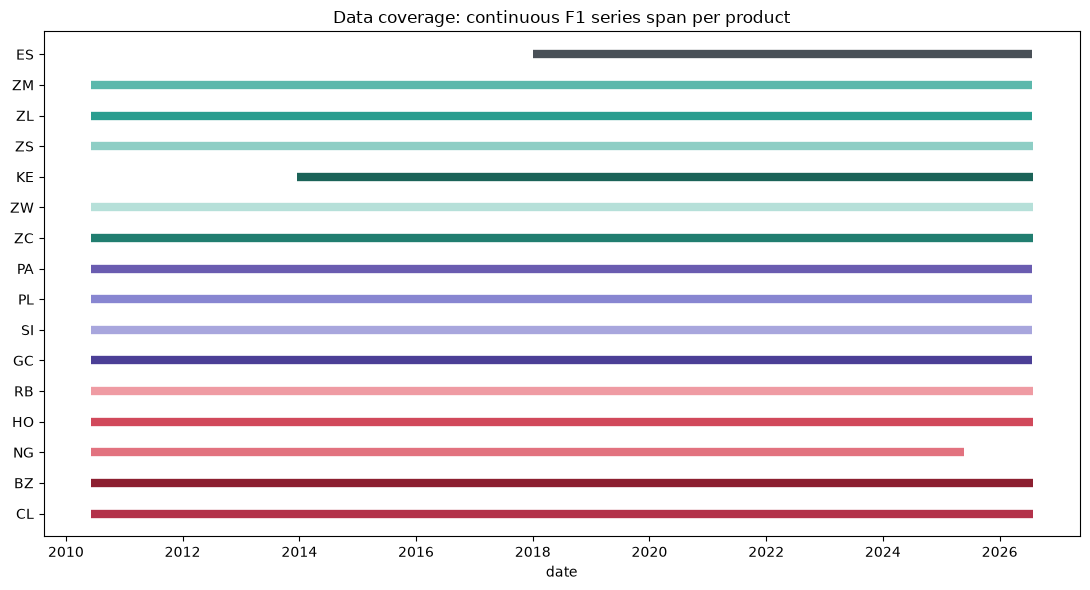

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
for i, p in enumerate(PRODUCTS):
    c = curve(p)
    ax.plot(
        [c["date"].min(), c["date"].max()],
        [i, i],
        lw=6,
        color=C.product_color(p),
        solid_capstyle="butt",
    )
ax.set_yticks(range(len(PRODUCTS)))
ax.set_yticklabels(PRODUCTS)
ax.set_title("Data coverage: continuous F1 series span per product")
ax.set_xlabel("date")
show(
    fig,
    "Data coverage Gantt - all 16 products span the full 2010-2026 development+holdout window (KE/ES start later).",
)

**hygiene before/after** - the GC junk contract vs a legitimate GC outright, same period.

Figure 2: Before/after hygiene: the flagged junk contract prints near-zero/negative while a real outright trades at real gold spot levels the same week.


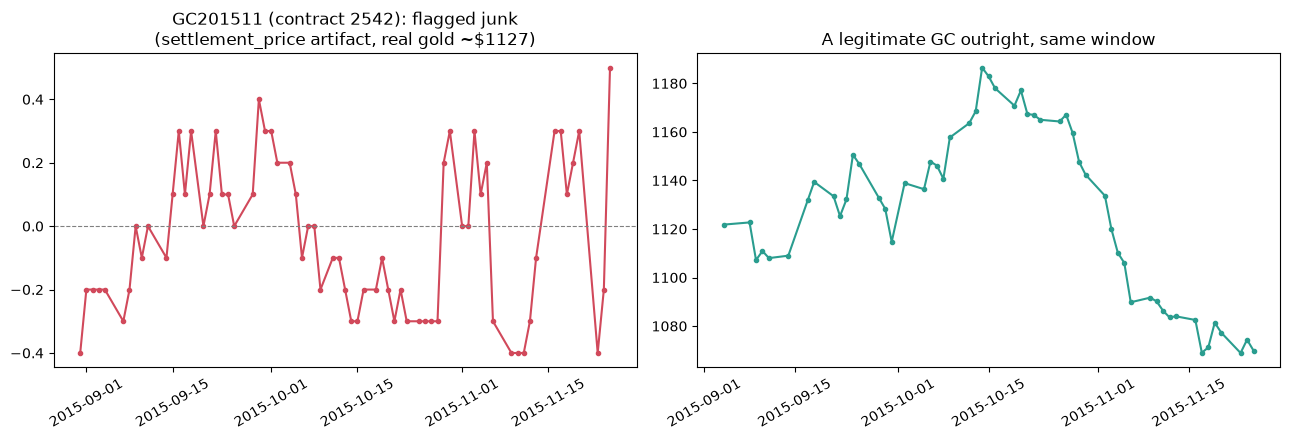

In [4]:
ohlcv_gc = pl.read_parquet("data/market/databento/ohlcv/GC.parquet").filter(
    pl.col("product") == "GC"
)
junk = ohlcv_gc.filter(pl.col("contract_id") == 2542).sort("date")
legit = ohlcv_gc.filter(
    (pl.col("date") >= junk["date"].min())
    & (pl.col("date") <= junk["date"].max())
    & (pl.col("volume") > 1000)
).sort("date")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(junk["date"], junk["close"], color="#d1495b", marker="o", ms=3)
axes[0].set_title(
    "GC201511 (contract 2542): flagged junk\n(settlement_price artifact, real gold ~$1127)"
)
axes[0].axhline(0, color="grey", lw=0.8, ls="--")
gc_by_contract = (
    legit.group_by("contract_id")
    .agg(pl.col("close").mean().alias("m"))
    .sort("m", descending=True)
)
best_contract = gc_by_contract["contract_id"][0] if gc_by_contract.height else None
if best_contract is not None:
    good = legit.filter(pl.col("contract_id") == best_contract).sort("date")
    axes[1].plot(good["date"], good["close"], color="#2a9d8f", marker="o", ms=3)
axes[1].set_title("A legitimate GC outright, same window")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
show(
    fig,
    "Before/after hygiene: the flagged junk contract prints near-zero/negative while a real outright trades at real gold spot levels the same week.",
)

**continuous price panel**, all 16 products, log scale, roll dates marked.

Figure 3: Continuous F1 price panel (log scale), all 16 products; black dots mark roll dates.


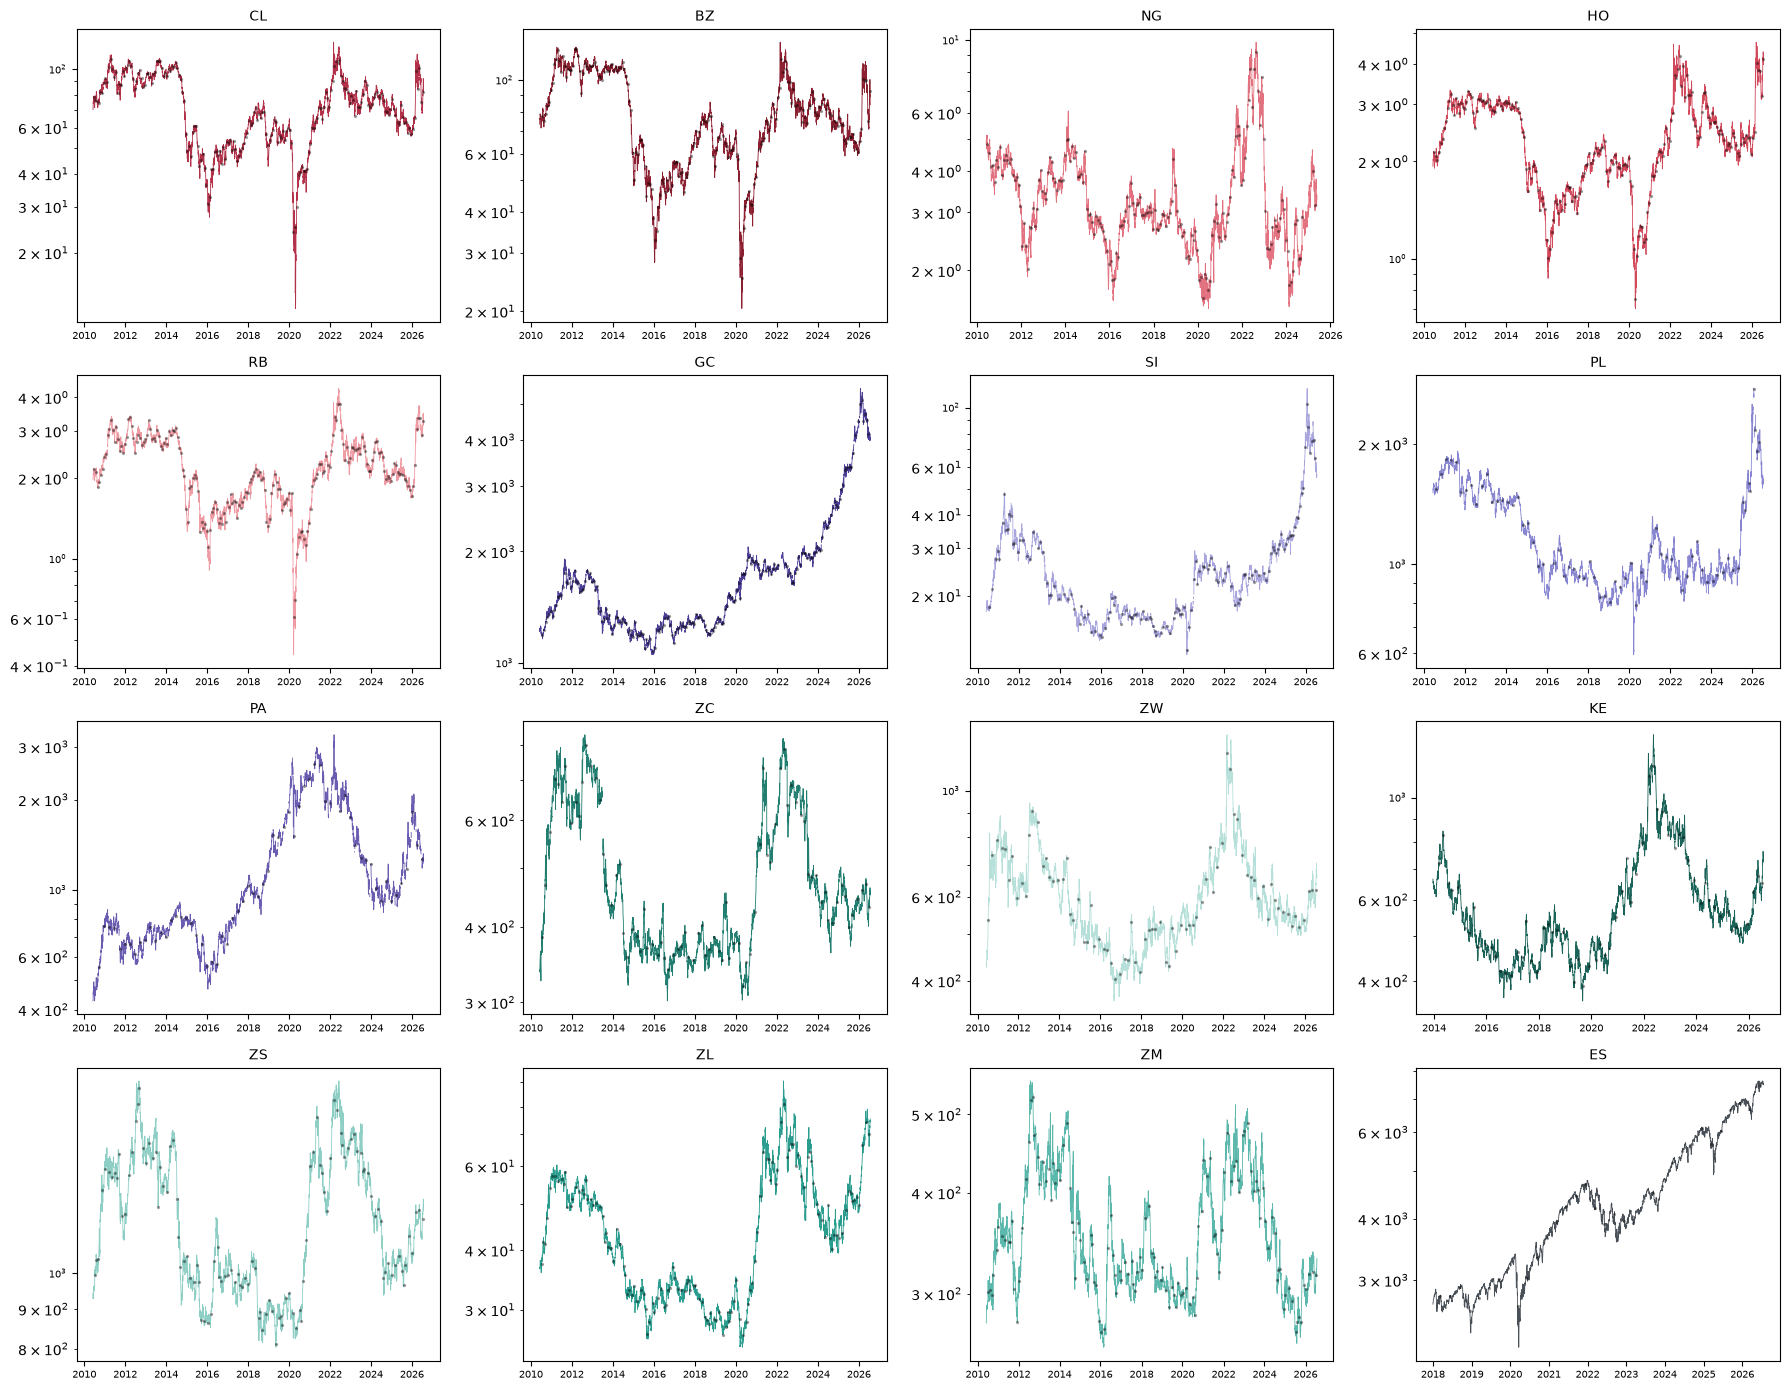

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14), sharex=False)
for ax, p in zip(axes.flat, PRODUCTS):
    c = curve(p)
    ax.plot(c["date"], c["close_f1"], color=C.product_color(p), lw=0.6)
    rolls = c.filter(pl.col("is_roll"))
    ax.scatter(
        rolls["date"], rolls["close_f1"], color="black", s=2, alpha=0.3, zorder=3
    )
    ax.set_yscale("log")
    ax.set_title(p, fontsize=10)
    ax.tick_params(labelsize=7)
show(
    fig,
    "Continuous F1 price panel (log scale), all 16 products; black dots mark roll dates.",
)

**adjusted vs unadjusted divergence** - CL's raw front-month price vs its ratio-adjusted continuous series.

Figure 4: Why the adjustment convention matters: the raw series jumps at every roll; the ratio-adjusted series does not, and never crosses zero.


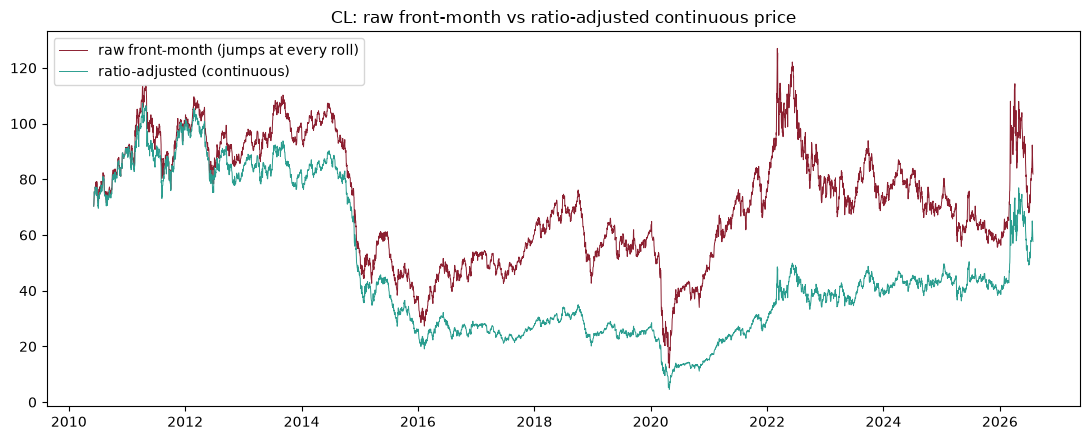

In [6]:
c = curve("CL")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(
    c["date"],
    c["close_f1"],
    label="raw front-month (jumps at every roll)",
    lw=0.7,
    color="#8c1f30",
)
ax.plot(
    c["date"],
    c["close_ratioadj"],
    label="ratio-adjusted (continuous)",
    lw=0.7,
    color="#2a9d8f",
)
ax.legend()
ax.set_title("CL: raw front-month vs ratio-adjusted continuous price")
show(
    fig,
    "Why the adjustment convention matters: the raw series jumps at every roll; the ratio-adjusted series does not, and never crosses zero.",
)

**validation scatters** - our CL/GC curve vs the ready-made `research/*_curve.parquet`.

Figure 5: Validation scatter vs the ready-made reference curve - close but not within-1-tick on every date (see Phase 0 writeup for the settlement-vs-close hypothesis).


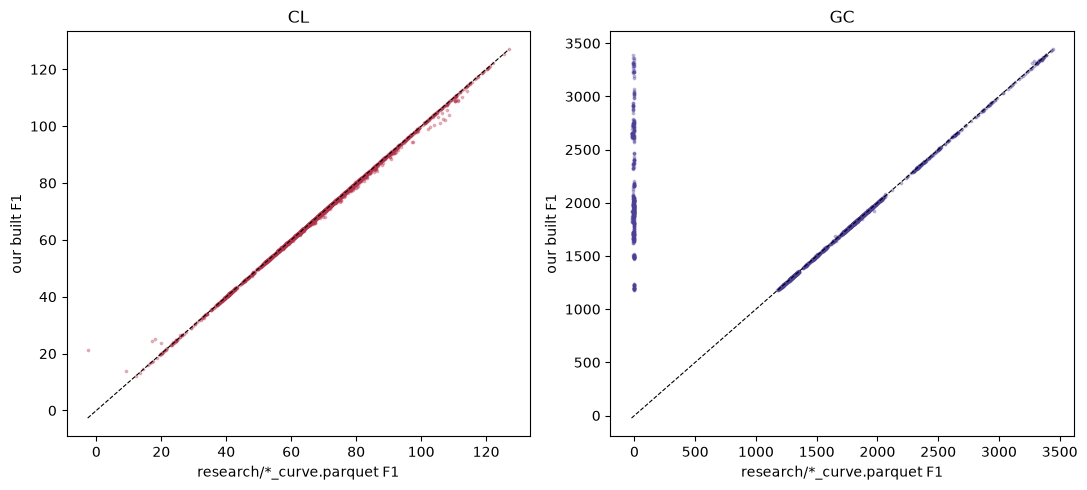

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, p, fname in zip(axes, ["CL", "GC"], ["cl_curve.parquet", "gc_curve.parquet"]):
    built = curve(p).select(["date", "close_f1"])
    ref = (
        pl.read_parquet(f"data/market/research/{fname}")
        .with_columns(pl.col("date").cast(pl.Date))
        .select(["date", pl.col("close_f1").alias("ref_f1")])
    )
    j = built.join(ref, on="date", how="inner").drop_nulls()
    ax.scatter(j["ref_f1"], j["close_f1"], s=3, alpha=0.3, color=C.product_color(p))
    lims = [j["ref_f1"].min(), j["ref_f1"].max()]
    ax.plot(lims, lims, color="black", lw=0.8, ls="--")
    ax.set_xlabel("research/*_curve.parquet F1")
    ax.set_ylabel("our built F1")
    ax.set_title(p)
show(
    fig,
    "Validation scatter vs the ready-made reference curve - close but not within-1-tick on every date (see Phase 0 writeup for the settlement-vs-close hypothesis).",
)

## Phase 1 - The tail atlas

Moments, Hill tail index (both tails), volatility clustering, the leverage effect,
Samuelson effect, and seasonality, on the ratio-adjusted continuous series (never the
back-adjusted one - see Phase 0 Bug 4).


In [8]:
phase1 = load("phase_1_results.json")
returns_cache = {}
for p in PRODUCTS:
    c = curve(p).filter(pl.col("log_return_ratioadj").is_finite())
    returns_cache[p] = c.select(["date", "log_return_ratioadj"]).to_numpy()

**return-distribution small multiples**, 16 panels, fitted normal overlaid.

Figure 6: Return distributions with fitted normal overlaid - every product visibly fatter-tailed/more-peaked than its own best-fit normal.


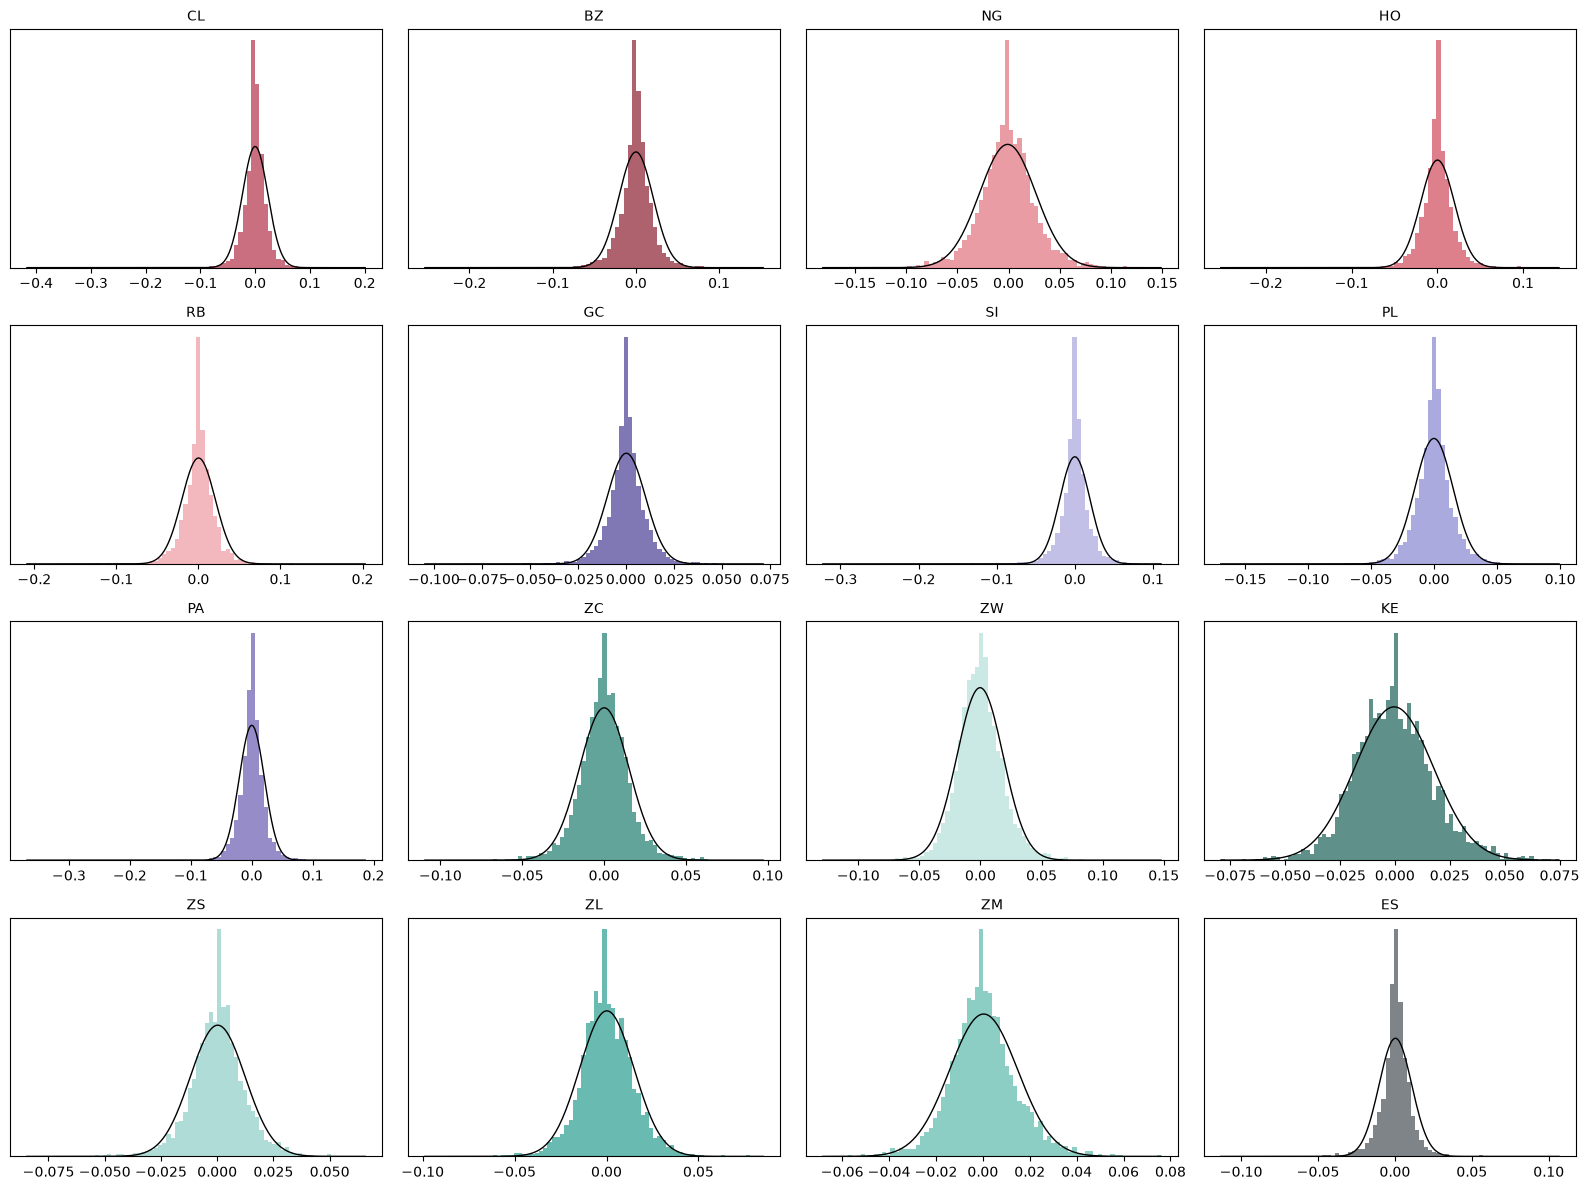

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, p in zip(axes.flat, PRODUCTS):
    r = returns_cache[p][:, 1].astype(float)
    ax.hist(r, bins=80, density=True, color=C.product_color(p), alpha=0.7)
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, st.norm.pdf(x, r.mean(), r.std()), color="black", lw=1)
    ax.set_title(p, fontsize=10)
    ax.set_yticks([])
show(
    fig,
    "Return distributions with fitted normal overlaid - every product visibly fatter-tailed/more-peaked than its own best-fit normal.",
)

**QQ-plot grid vs normal**.

Figure 7: QQ-plots vs normal - systematic S-curves in every panel, the visual signature of fat tails.


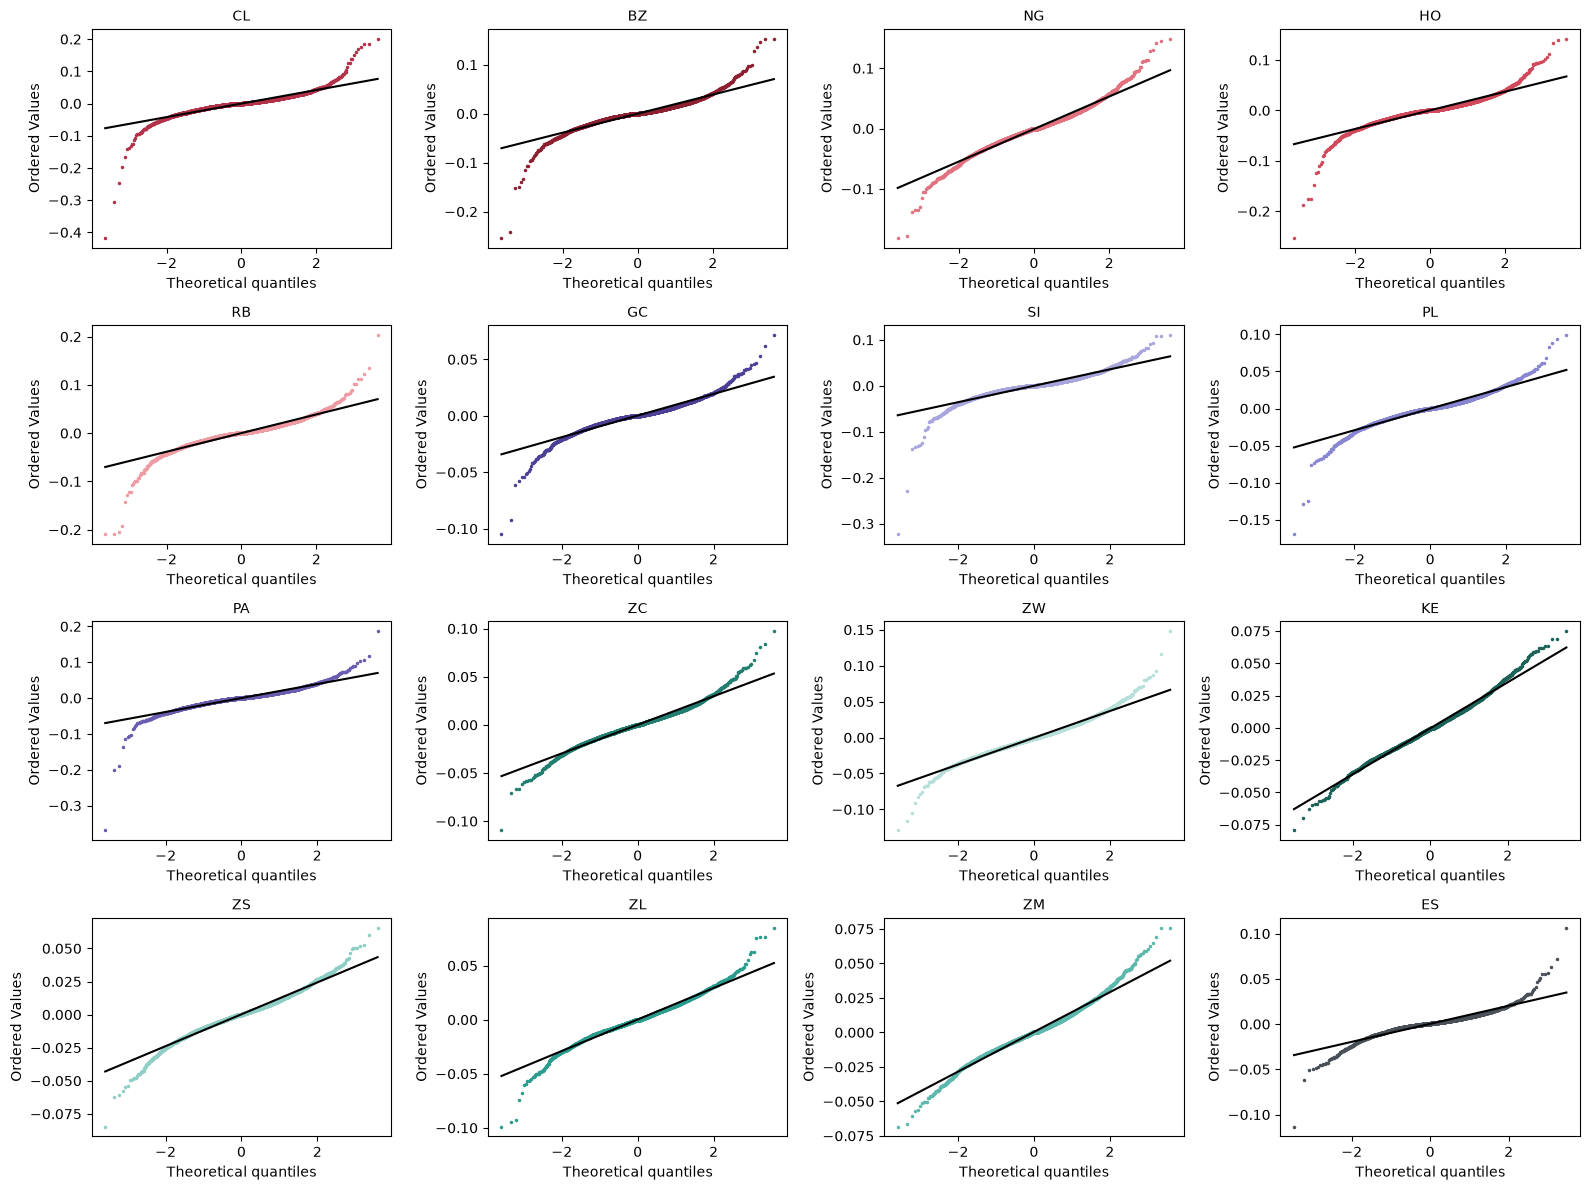

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, p in zip(axes.flat, PRODUCTS):
    r = returns_cache[p][:, 1].astype(float)
    st.probplot(r, dist="norm", plot=ax)
    ax.set_title(p, fontsize=10)
    ax.get_lines()[0].set_markersize(1.5)
    ax.get_lines()[0].set_color(C.product_color(p))
    ax.get_lines()[1].set_color("black")
show(
    fig,
    "QQ-plots vs normal - systematic S-curves in every panel, the visual signature of fat tails.",
)

**QQ-plot grid vs each product's own best-fit family** (from Phase 3's OOS ranking, fit directly on standardized returns for this illustration).

Figure 8: QQ-plots vs each product's own best-fit family - visibly straighter than the normal QQ grid above, though not perfect (this fits the family on the raw returns, not GARCH-standardized residuals, so it understates how well Phase 3's actual conditional models fit).


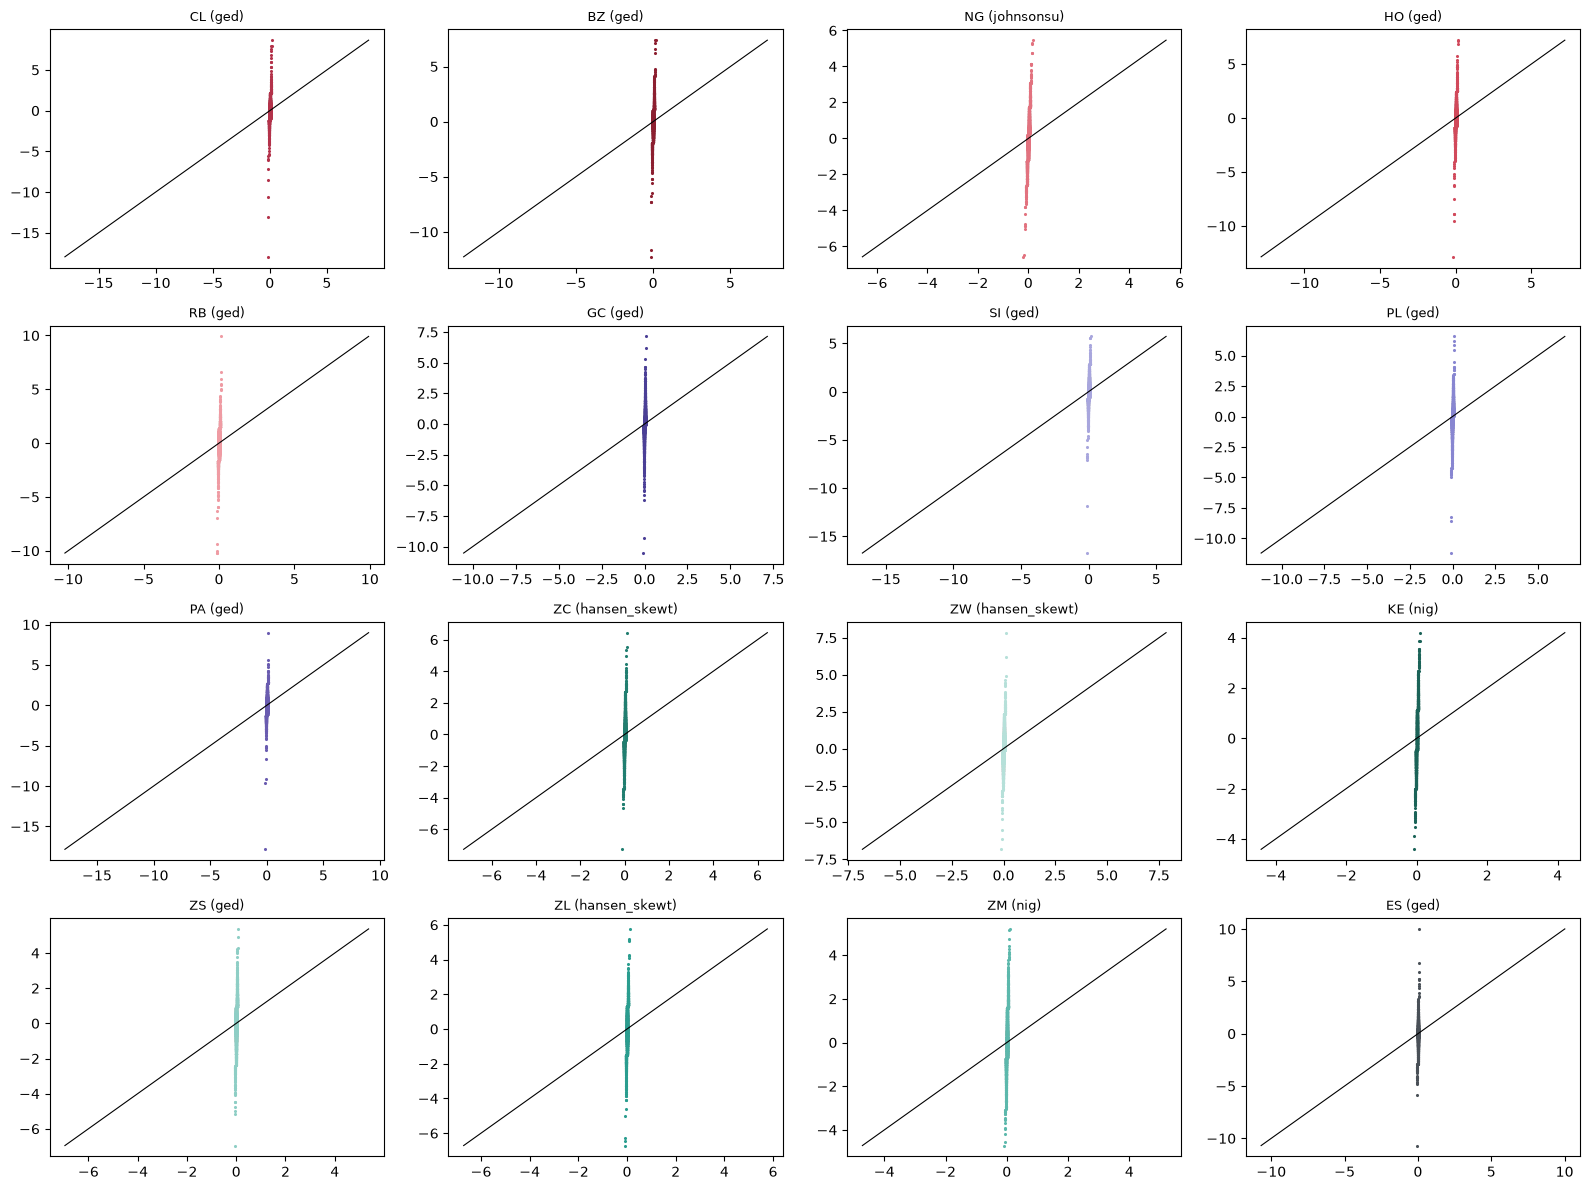

In [11]:
phase3_families = load("phase_3_results.json")
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, p in zip(axes.flat, PRODUCTS):
    r = returns_cache[p][:, 1].astype(float)
    best_model = phase3_families[p]["best_model"]
    fam = best_model.split("_", 1)[1] if "_" in best_model else best_model
    model = C.fit_risk_model(r, p, fam)
    if model is None:
        continue
    z = np.sort((r - model.mean) / model.std)
    u = (np.arange(1, len(z) + 1) - 0.5) / len(z)
    theo = model.ppf_from_u(u)
    ax.scatter(theo, z, s=1.5, color=C.product_color(p))
    lims = [min(theo.min(), z.min()), max(theo.max(), z.max())]
    ax.plot(lims, lims, color="black", lw=0.8)
    ax.set_title(f"{p} ({fam})", fontsize=9)
show(
    fig,
    "QQ-plots vs each product's own best-fit family - visibly straighter than the normal QQ grid above, though not perfect (this fits the family on the raw returns, not GARCH-standardized residuals, so it understates how well Phase 3's actual conditional models fit).",
)

**Hill plots** (alpha vs k) with the detected plateau marked, both tails, per product.

Figure 9: Hill alpha-vs-k plots, both tails; shaded bands mark the detected plateau region used for the alpha estimate.


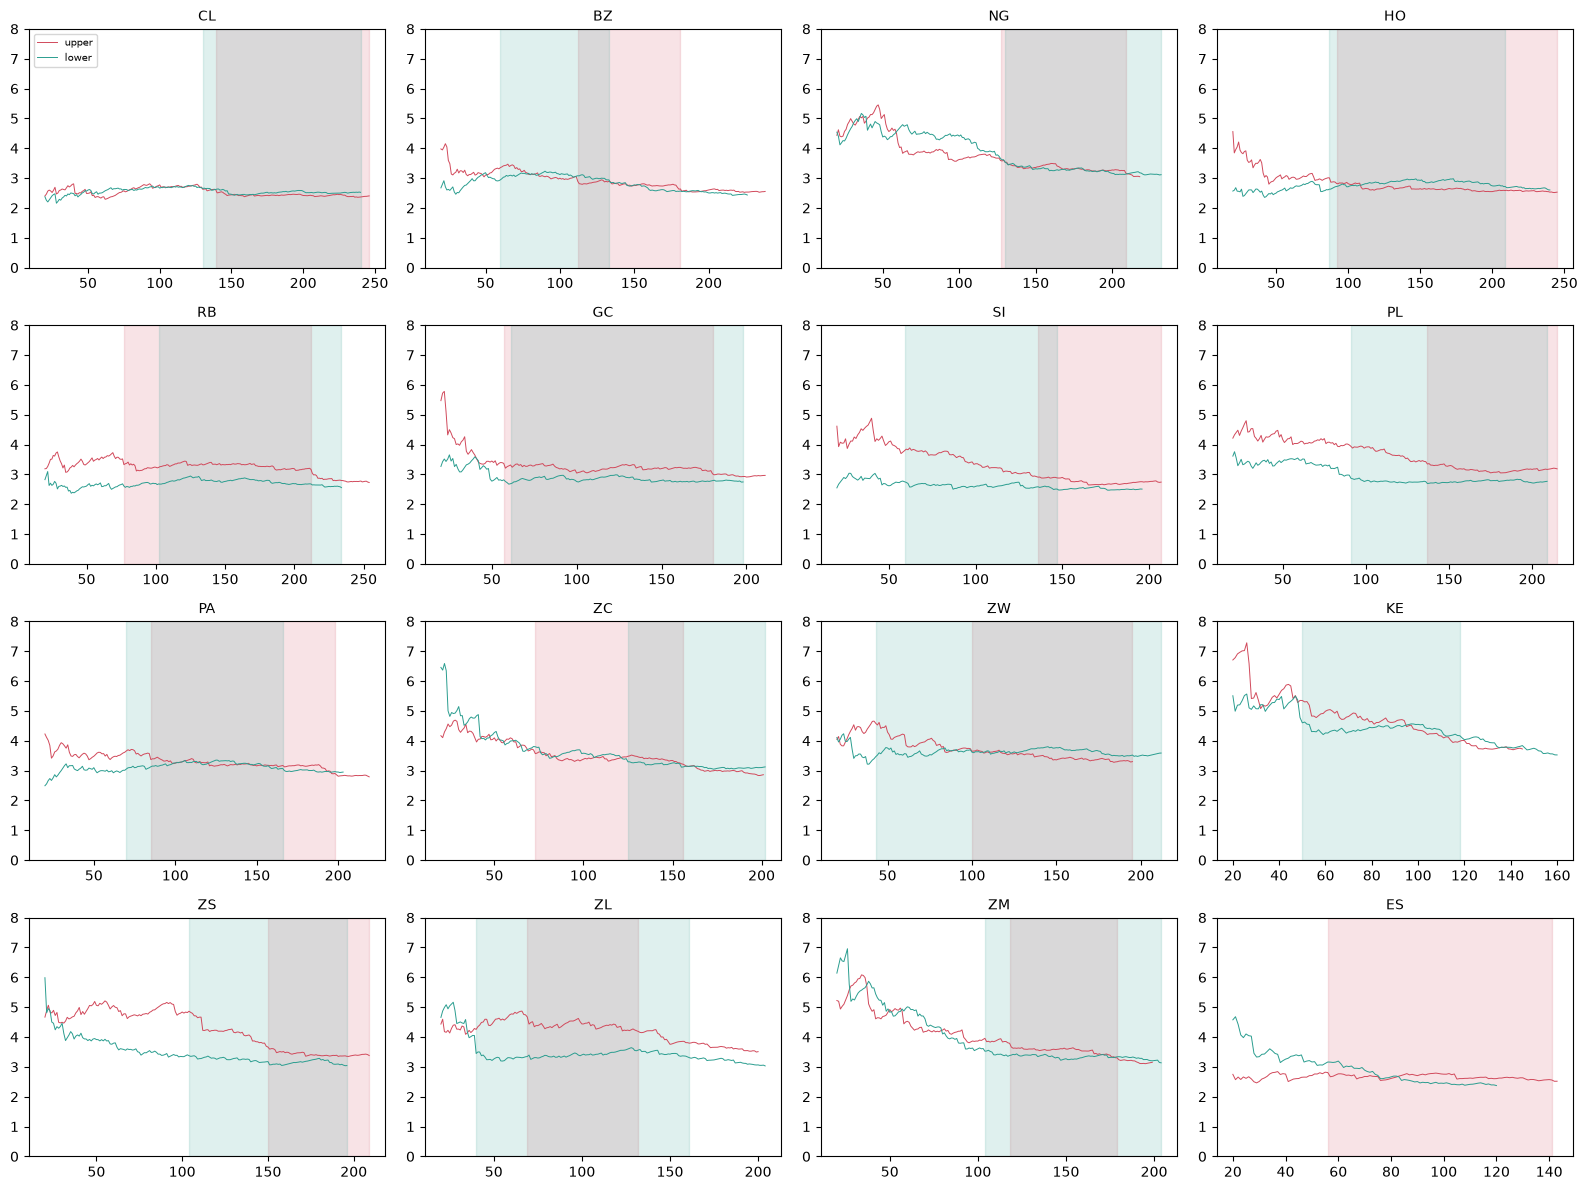

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, p in zip(axes.flat, PRODUCTS):
    r = returns_cache[p][:, 1].astype(float)
    for tail, color in [("upper", "#d1495b"), ("lower", "#2a9d8f")]:
        path = L5.hill_alpha_path(r, tail=tail, k_min=20)
        ax.plot(path["k"], path["alpha"], color=color, lw=0.7, label=tail)
        plateau = L5.find_hill_plateau(path["alpha"], path["k"])
        if plateau.get("found"):
            ax.axvspan(plateau["k_lo"], plateau["k_hi"], color=color, alpha=0.15)
    ax.set_ylim(0, 8)
    ax.set_title(p, fontsize=10)
axes.flat[0].legend(fontsize=7)
show(
    fig,
    "Hill alpha-vs-k plots, both tails; shaded bands mark the detected plateau region used for the alpha estimate.",
)

**tail-asymmetry chart** - alpha_left vs alpha_right, the sec 3.1 money plot (Gate CA).

Figure 10: alpha_left vs alpha_right per product - no clean split above/below the diagonal; Gate CA does not fire (5/14 match the predicted sign).


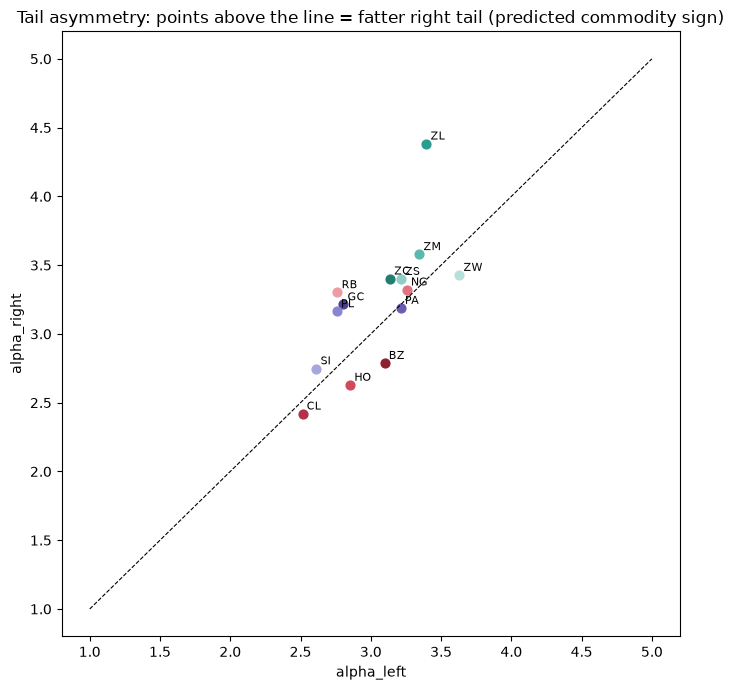

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
for p in PRODUCTS:
    h = phase1[p]["hill"]
    left = h["lower"].get("alpha_median") if h["lower"].get("found") else None
    right = h["upper"].get("alpha_median") if h["upper"].get("found") else None
    if left and right:
        ax.scatter(left, right, color=C.product_color(p), s=40)
        ax.annotate(
            p, (left, right), fontsize=8, xytext=(3, 3), textcoords="offset points"
        )
lims = [1, 5]
ax.plot(lims, lims, color="black", lw=0.8, ls="--")
ax.set_xlabel("alpha_left")
ax.set_ylabel("alpha_right")
ax.set_title(
    "Tail asymmetry: points above the line = fatter right tail (predicted commodity sign)"
)
show(
    fig,
    "alpha_left vs alpha_right per product - no clean split above/below the diagonal; Gate CA does not fire (5/14 match the predicted sign).",
)

**excess-kurtosis bar chart**, commodities vs ES.

Figure 11: Excess kurtosis by product - every product is decisively non-normal; ES sits mid-pack, not an outlier low end.


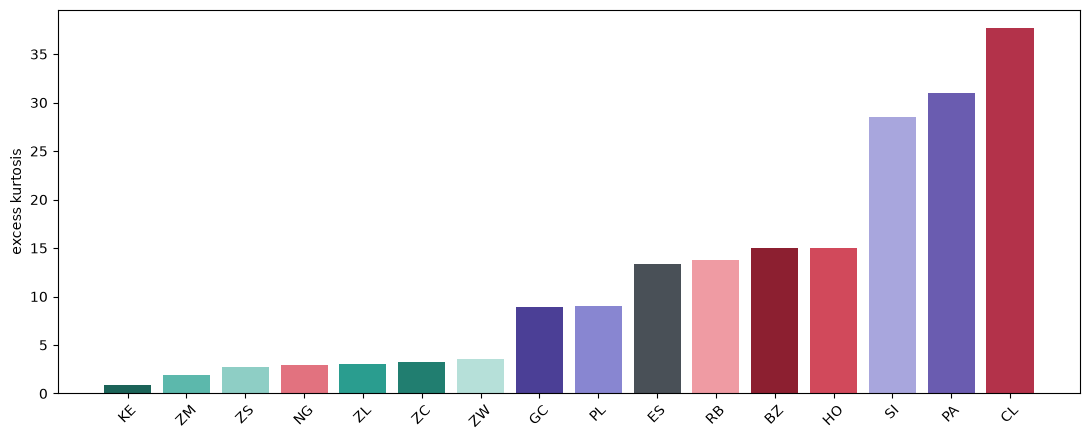

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.5))
vals = [(p, phase1[p]["moments"]["excess_kurtosis"]) for p in PRODUCTS]
vals.sort(key=lambda x: x[1])
ax.bar(
    [v[0] for v in vals],
    [v[1] for v in vals],
    color=[C.product_color(v[0]) for v in vals],
)
ax.set_ylabel("excess kurtosis")
ax.tick_params(axis="x", rotation=45)
show(
    fig,
    "Excess kurtosis by product - every product is decisively non-normal; ES sits mid-pack, not an outlier low end.",
)

**ACF grids** of r, |r|, r^2 for one representative product (CL) plus the vol-clustering summary across all 16.

Figure 12: CL's ACF of r (no memory), |r|, and r^2 (both show clear volatility-clustering memory) - the standard stylised-fact triad.


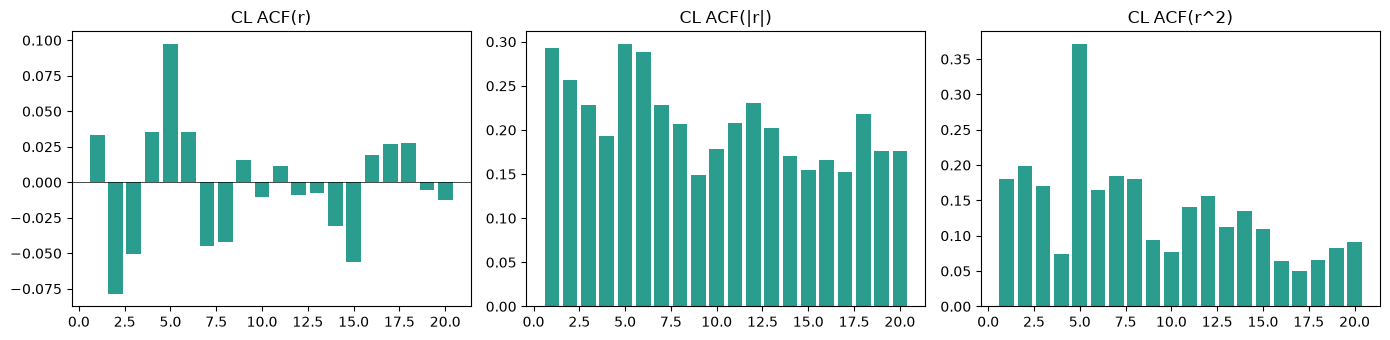

In [15]:
r = returns_cache["CL"][:, 1].astype(float)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (arr, name) in zip(axes, [(r, "r"), (np.abs(r), "|r|"), (r**2, "r^2")]):
    acf = C.acf(arr, 20)
    ax.bar(range(1, 21), acf, color="#2a9d8f")
    ax.set_title(f"CL ACF({name})")
    ax.axhline(0, color="black", lw=0.5)
show(
    fig,
    "CL's ACF of r (no memory), |r|, and r^2 (both show clear volatility-clustering memory) - the standard stylised-fact triad.",
)

**volatility-clustering heatmap** - rolling 20d vol, product x time.

Figure 13: Rolling 20-day annualised vol, product x time - visible cross-product spikes at 2020 (COVID/negative WTI) and 2022 (Ukraine).


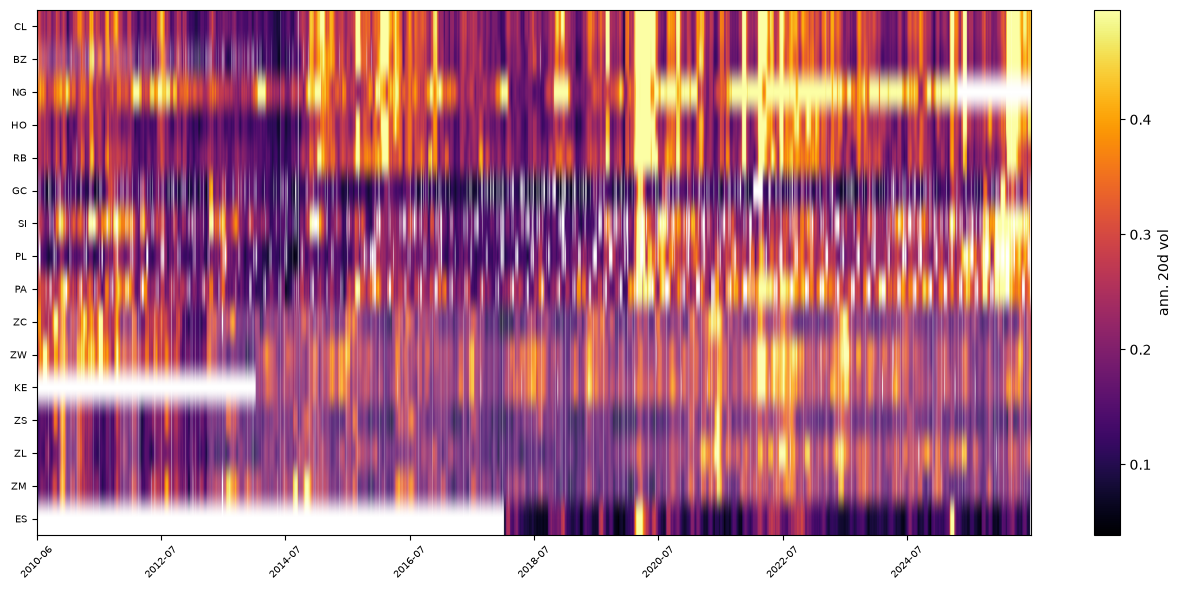

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))
vol_rows = []
for p in PRODUCTS:
    c = curve(p).filter(pl.col("log_return_ratioadj").is_finite())
    c = c.with_columns(
        (
            pl.col("log_return_ratioadj").rolling_std(window_size=20) * np.sqrt(252)
        ).alias("vol20")
    )
    vol_rows.append(
        c.select(["date", "vol20"]).with_columns(pl.lit(p).alias("product"))
    )
vol_panel = pl.concat(vol_rows).drop_nulls()
piv = vol_panel.pivot(on="product", index="date", values="vol20").sort("date")
dates_arr = piv["date"].to_numpy()
mat = piv.select([p for p in PRODUCTS if p in piv.columns]).to_numpy().T
im = ax.imshow(
    mat,
    aspect="auto",
    cmap="inferno",
    vmax=np.nanpercentile(mat, 95),
    extent=[0, len(dates_arr), len(PRODUCTS), 0],
)
ax.set_yticks(np.arange(len(PRODUCTS)) + 0.5)
ax.set_yticklabels(PRODUCTS, fontsize=7)
step = len(dates_arr) // 8
ax.set_xticks(range(0, len(dates_arr), step))
ax.set_xticklabels(
    [str(dates_arr[i])[:7] for i in range(0, len(dates_arr), step)],
    rotation=45,
    fontsize=7,
)
plt.colorbar(im, ax=ax, label="ann. 20d vol")
show(
    fig,
    "Rolling 20-day annualised vol, product x time - visible cross-product spikes at 2020 (COVID/negative WTI) and 2022 (Ukraine).",
)

**Samuelson effect** - vol vs days-to-expiry, per product.

Figure 14: Realised vol by days-to-expiry bucket - the Samuelson effect, where present, shows as rising vol toward dte=0.


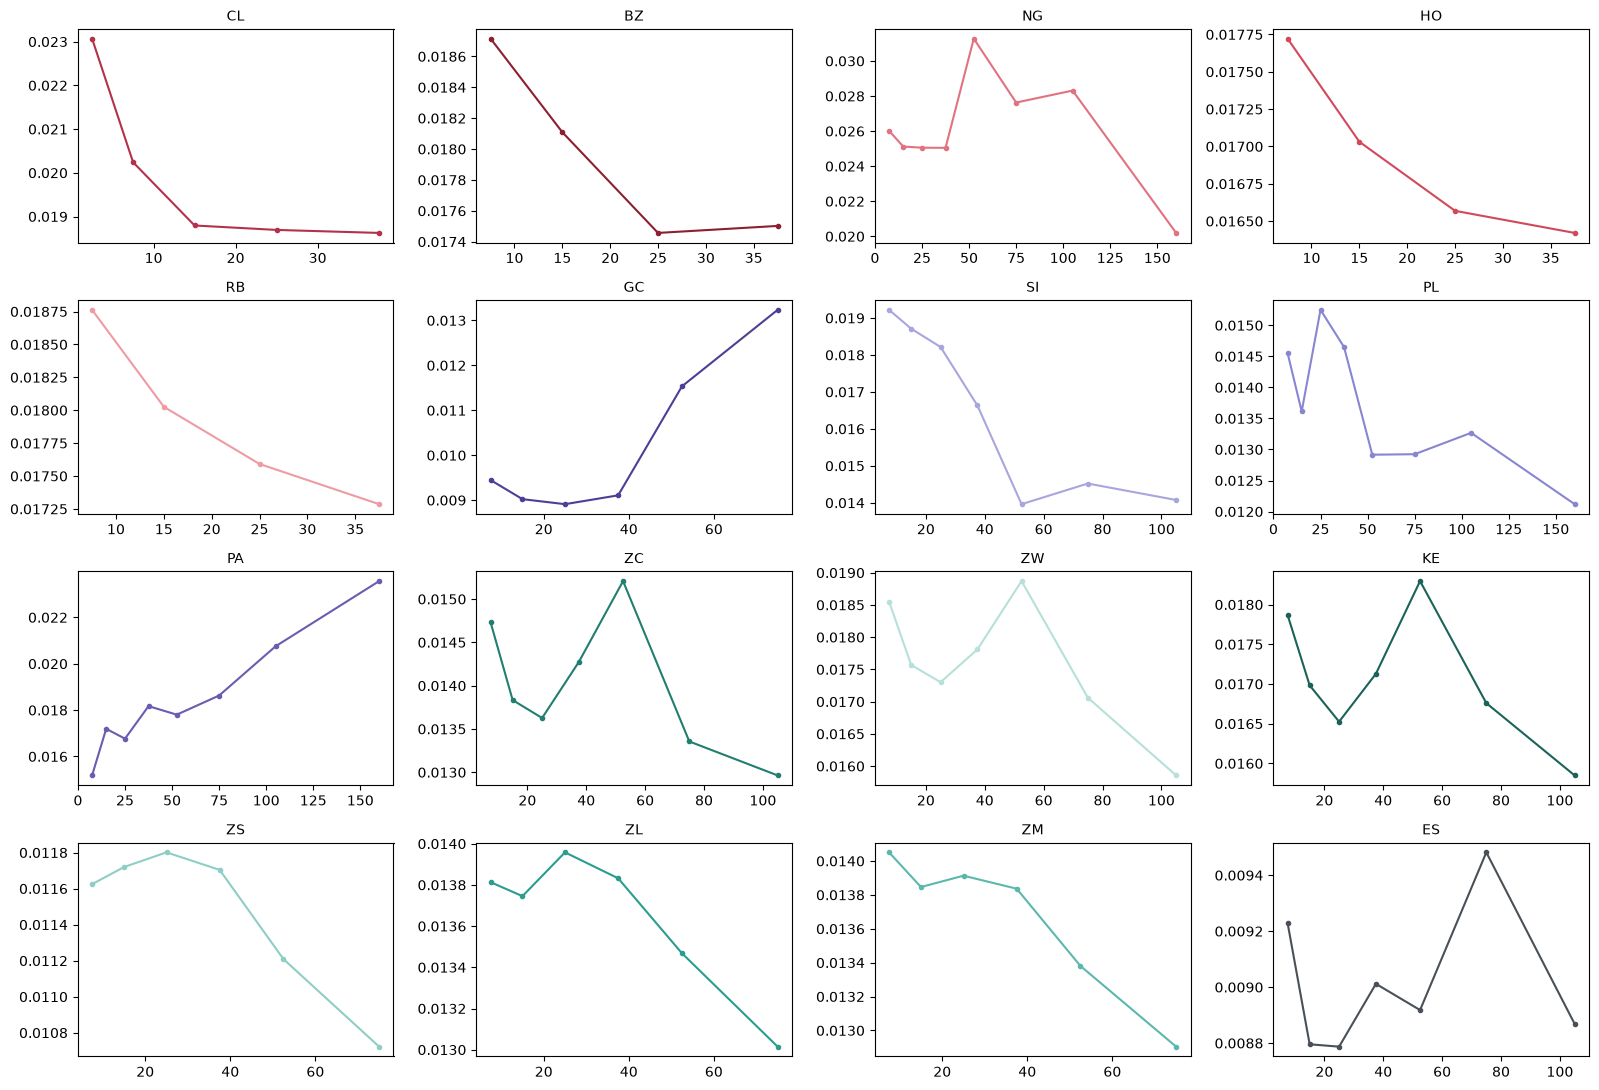

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(16, 11))
for ax, p in zip(axes.flat, PRODUCTS):
    buckets = phase1[p].get("samuelson", {}).get("buckets", [])
    if buckets:
        mids = [(b["dte_lo"] + min(b["dte_hi"], 200)) / 2 for b in buckets]
        vols = [b["mean_vol"] for b in buckets]
        ax.plot(mids, vols, marker="o", ms=3, color=C.product_color(p))
    ax.set_title(p, fontsize=10)
show(
    fig,
    "Realised vol by days-to-expiry bucket - the Samuelson effect, where present, shows as rising vol toward dte=0.",
)

**seasonality heatmap** - month-of-year mean return, product x month.

Figure 15: Month-of-year mean return heatmap (bps/day) - NG's winter months and the grain growing-season months show visible patterns.


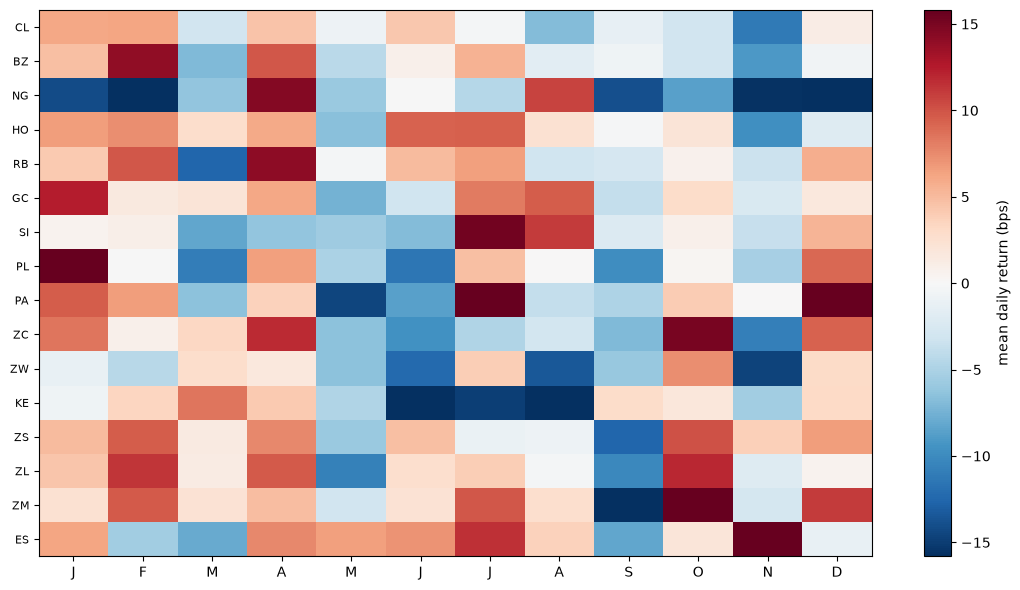

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
mat = np.full((len(PRODUCTS), 12), np.nan)
for i, p in enumerate(PRODUCTS):
    for m in phase1[p]["month_of_year"]["months"]:
        mat[i, m["month"] - 1] = m["mean_return"] * 1e4
vmax = np.nanpercentile(np.abs(mat), 95)
im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_yticks(range(len(PRODUCTS)))
ax.set_yticklabels(PRODUCTS, fontsize=8)
ax.set_xticks(range(12))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
plt.colorbar(im, ax=ax, label="mean daily return (bps)")
show(
    fig,
    "Month-of-year mean return heatmap (bps/day) - NG's winter months and the grain growing-season months show visible patterns.",
)

**leverage-effect scatter** - corr(return, next-period vol) per product with bootstrap CIs.

Figure 16: Leverage-effect correlation with bootstrap CIs - mostly zero-including; where PA is significant, it is the EQUITY sign, not the predicted inverse-leverage sign.


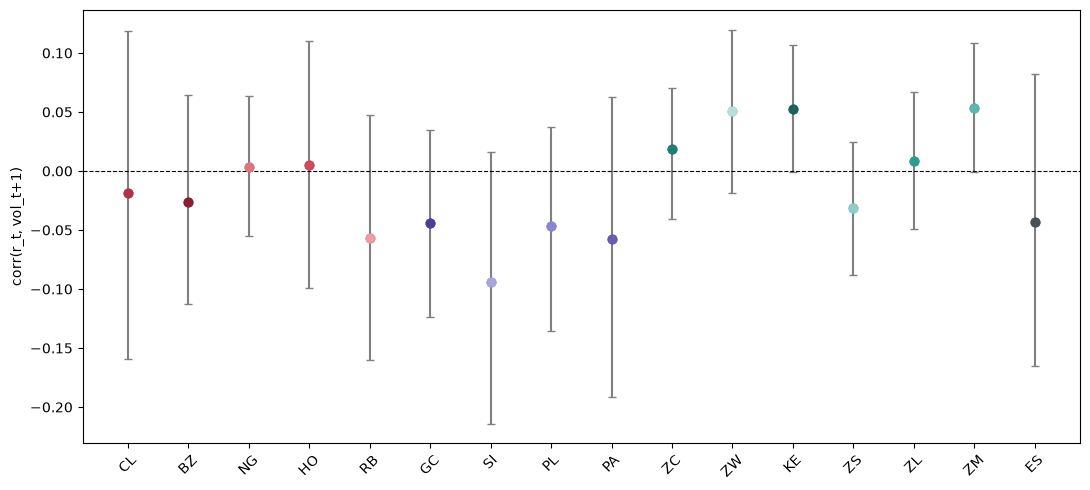

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
xs = list(range(len(PRODUCTS)))
corrs = [phase1[p]["leverage"]["corr"] for p in PRODUCTS]
los = [phase1[p]["leverage"]["ci_lo"] for p in PRODUCTS]
his = [phase1[p]["leverage"]["ci_hi"] for p in PRODUCTS]
colors = [C.product_color(p) for p in PRODUCTS]
ax.errorbar(
    xs,
    corrs,
    yerr=[np.array(corrs) - np.array(los), np.array(his) - np.array(corrs)],
    fmt="o",
    ecolor="grey",
    capsize=3,
)
for x, y, c in zip(xs, corrs, colors):
    ax.scatter(x, y, color=c, zorder=3, s=40)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(xs)
ax.set_xticklabels(PRODUCTS, rotation=45)
ax.set_ylabel("corr(r_t, vol_t+1)")
show(
    fig,
    "Leverage-effect correlation with bootstrap CIs - mostly zero-including; where PA is significant, it is the EQUITY sign, not the predicted inverse-leverage sign.",
)

## Phase 2 - Unconditional density selection

Seven families, expanding-window walk-forward OOS log score. Five distinct families win
somewhere; no product's win clears BH-significance individually.


In [20]:
phase2 = load("phase_2_results.json")
print(json.dumps(phase2["_family_map_summary"], indent=2))

{
  "winners": {
    "CL": "t",
    "BZ": "t",
    "NG": "ged",
    "HO": "ged",
    "RB": "t",
    "GC": "ged",
    "SI": "ged",
    "PL": "ged",
    "PA": "johnsonsu",
    "ZC": "hansen_skewt",
    "ZW": "hansen_skewt",
    "KE": "hansen_skewt",
    "ZS": "ged",
    "ZL": "t",
    "ZM": "nig",
    "ES": "ged",
    "BTCUSDT": "johnsonsu"
  },
  "distinct_families_that_win_somewhere": [
    "ged",
    "hansen_skewt",
    "johnsonsu",
    "nig",
    "t"
  ],
  "n_distinct": 5
}


**family-map heatmap** - product x family, OOS log-score rank.

Figure 17: Phase 2 family-map heatmap (unconditional): darker = better rank. GED and Hansen skew-t dominate the top ranks.


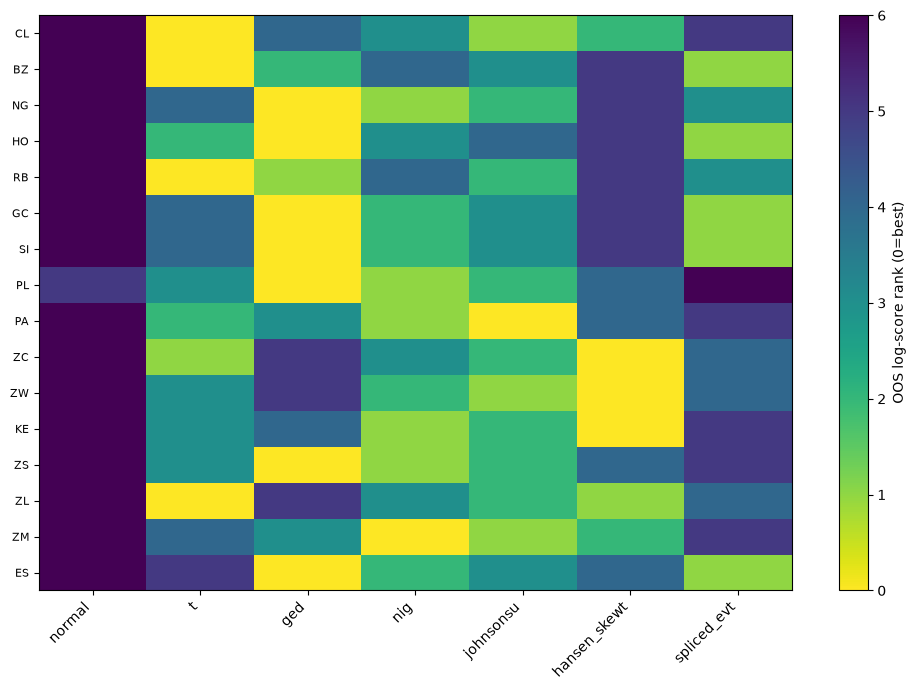

In [21]:
families_p2 = phase2["_config"]["families"]
mat = np.full((len(PRODUCTS), len(families_p2)), np.nan)
for i, p in enumerate(PRODUCTS):
    ranking = phase2[p]["ranking"]
    for rank, fam in enumerate(ranking):
        j = families_p2.index(fam)
        mat[i, j] = rank
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(mat, cmap="viridis_r", aspect="auto")
ax.set_yticks(range(len(PRODUCTS)))
ax.set_yticklabels(PRODUCTS, fontsize=8)
ax.set_xticks(range(len(families_p2)))
ax.set_xticklabels(families_p2, rotation=45, ha="right")
plt.colorbar(im, ax=ax, label="OOS log-score rank (0=best)")
show(
    fig,
    "Phase 2 family-map heatmap (unconditional): darker = better rank. GED and Hansen skew-t dominate the top ranks.",
)

**PIT histograms** for CL's best (t) and worst (normal) family.

Figure 18: PIT histograms - a flat histogram means well-calibrated; the best family (t) is visibly flatter than normal.


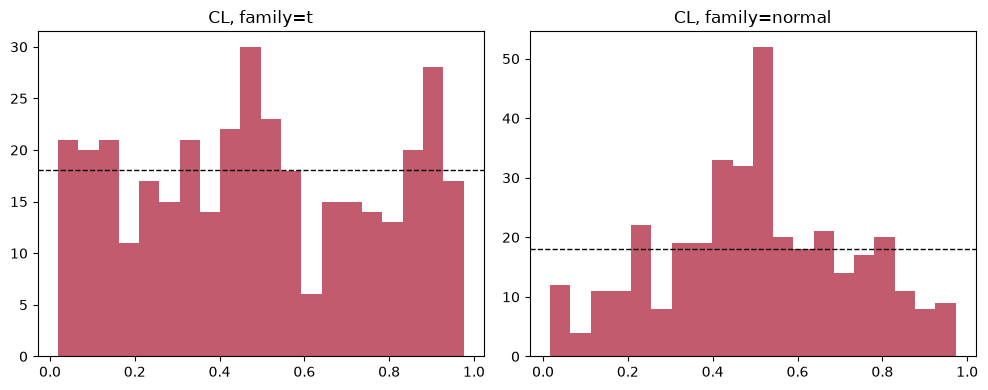

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, fam in zip(axes, ["t", "normal"]):
    pit = phase2["CL"]["pit_ks"].get(fam, {}).get("pit_sample", [])
    if pit:
        ax.hist(pit, bins=20, color=C.product_color("CL"), alpha=0.8)
    ax.axhline(len(pit) / 20 if pit else 0, color="black", lw=1, ls="--")
    ax.set_title(f"CL, family={fam}")
show(
    fig,
    "PIT histograms - a flat histogram means well-calibrated; the best family (t) is visibly flatter than normal.",
)

## Phase 3 - Conditional models and the risk battery (the replication test)

GARCH(1,1)/GJR(1,1,1) x 6 innovations + spliced-EVT, rolling OOS. GARCH-GED dominates (9/16
products), a genuine departure from crypto's GARCH-t. Gate CE (Acerbi-Szekely) is the
cleanest result in the notebook: 15/16 reject at 1%, both tails, BH-adjusted.


In [23]:
phase3 = load("phase_3_results.json")
phase3b = load("phase_3b_gate_ce_results.json")
print(json.dumps(phase3["_summary"], indent=2))
print()
print("Gate CE:", json.dumps(phase3b["gate_CE"], indent=2))

{
  "winners": {
    "CL": "garch_ged",
    "BZ": "garch_ged",
    "NG": "garch_johnsonsu",
    "HO": "garch_ged",
    "RB": "garch_ged",
    "GC": "garch_ged",
    "SI": "garch_ged",
    "PL": "garch_ged",
    "PA": "garch_ged",
    "ZC": "garch_hansen_skewt",
    "ZW": "garch_hansen_skewt",
    "KE": "garch_nig",
    "ZS": "garch_ged",
    "ZL": "garch_hansen_skewt",
    "ZM": "garch_nig",
    "ES": "gjr_ged"
  },
  "distinct_winners": [
    "garch_ged",
    "garch_hansen_skewt",
    "garch_johnsonsu",
    "garch_nig",
    "gjr_ged"
  ]
}

Gate CE: {
  "n_products_rejecting_1pct_both_tails_bh": 15,
  "n_products_total": 16,
  "threshold": 14,
  "fires": true
}


**illustrative rolling GARCH parameter path** (omega/alpha/beta persistence, CL, GARCH-normal) - a fresh, lightweight fit for illustration since Phase 3's full per-refit parameter paths were not persisted to JSON (too large across 13 models x 16 products).

Figure 19: Rolling GARCH persistence (alpha+beta) across refits - stays high (>0.9), consistent with the slow-decaying vol clustering seen in Figure 12.


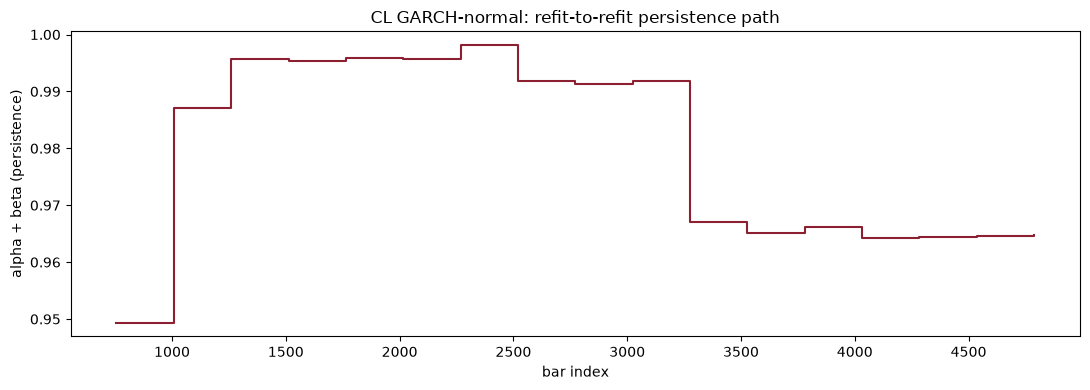

In [24]:
import dist_lib as L

r = returns_cache["CL"][:, 1].astype(float)
fc, fits = L.rolling_garch_forecast(
    r, refit_every=252, min_train=750, innovation="normal", max_train=2000
)
fig, ax = plt.subplots(figsize=(11, 4))
ts = [f["t"] for f in fits]
persistence = [f["alpha"] + f["beta"] for f in fits]
ax.step(ts, persistence, where="post", color="#8c1f30")
ax.set_ylabel("alpha + beta (persistence)")
ax.set_xlabel("bar index")
ax.set_title("CL GARCH-normal: refit-to-refit persistence path")
show(
    fig,
    "Rolling GARCH persistence (alpha+beta) across refits - stays high (>0.9), consistent with the slow-decaying vol clustering seen in Figure 12.",
)

**GARCH conditional-vol path** with named events annotated (CL).

Figure 20: CL's conditional vol path with named events marked - visible spikes at 2020-04 and 2022-02.


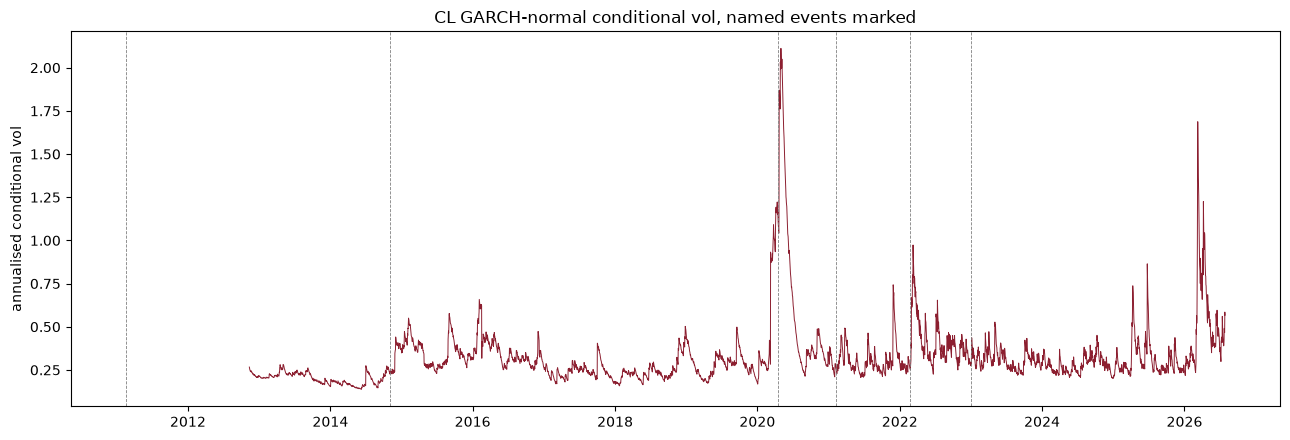

In [25]:
dates_cl = returns_cache["CL"][:, 0]
sigma = np.sqrt(np.where(fc > 0, fc, np.nan)) * np.sqrt(252)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(dates_cl, sigma, color="#8c1f30", lw=0.7)
for ev in C.NAMED_EVENTS:
    if "CL" not in ev["products"]:
        continue
    ev_date = date.fromisoformat(ev["start"])
    ax.axvline(ev_date, color="grey", lw=0.6, ls="--")
ax.set_ylabel("annualised conditional vol")
ax.set_title("CL GARCH-normal conditional vol, named events marked")
show(
    fig,
    "CL's conditional vol path with named events marked - visible spikes at 2020-04 and 2022-02.",
)

**VaR-violation timeline** - CL, GARCH-normal 1% VaR, actual returns and violations.

Figure 21: VaR-violation timeline for CL - 78 violations out of 4255 bars (1.83%, target 1%).


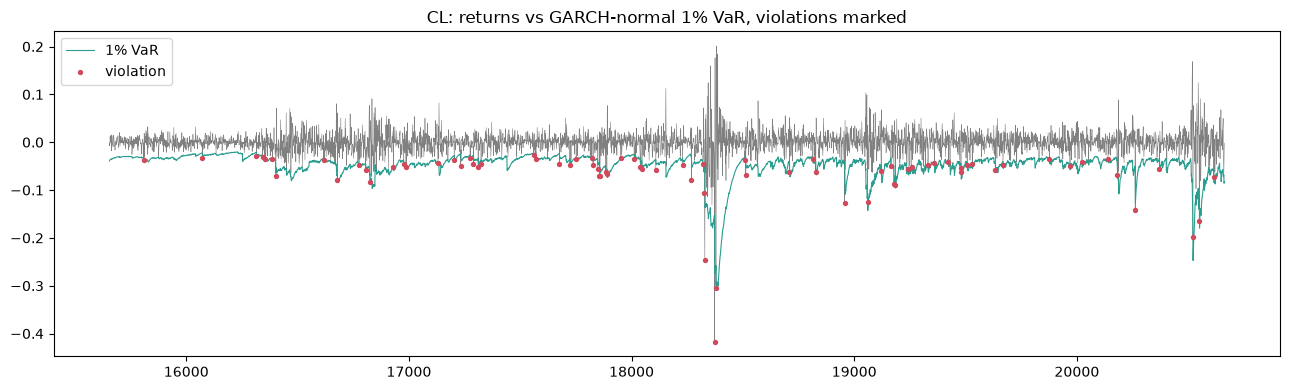

In [26]:
var01 = L5.normal_quantile_forecasts(fc, quantiles=[0.01])[0.01]
mask = np.isfinite(r) & np.isfinite(var01)
hits = r[mask] < var01[mask]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dates_cl[mask], r[mask], color="grey", lw=0.4)
ax.plot(dates_cl[mask], var01[mask], color="#2a9d8f", lw=0.8, label="1% VaR")
ax.scatter(
    dates_cl[mask][hits],
    r[mask][hits],
    color="#d1495b",
    s=8,
    zorder=3,
    label="violation",
)
ax.legend()
ax.set_title("CL: returns vs GARCH-normal 1% VaR, violations marked")
show(
    fig,
    f"VaR-violation timeline for CL - {hits.sum()} violations out of {mask.sum()} bars ({hits.mean() * 100:.2f}%, target 1%).",
)

**coverage-battery heatmap** - model x test x product pass/fail, at the 1% level.

Figure 22: Coverage-battery pass/fail (1% level, Kupiec+Christoffersen both pass=green) - most models pass on most products; failures cluster on specific product/model combinations.


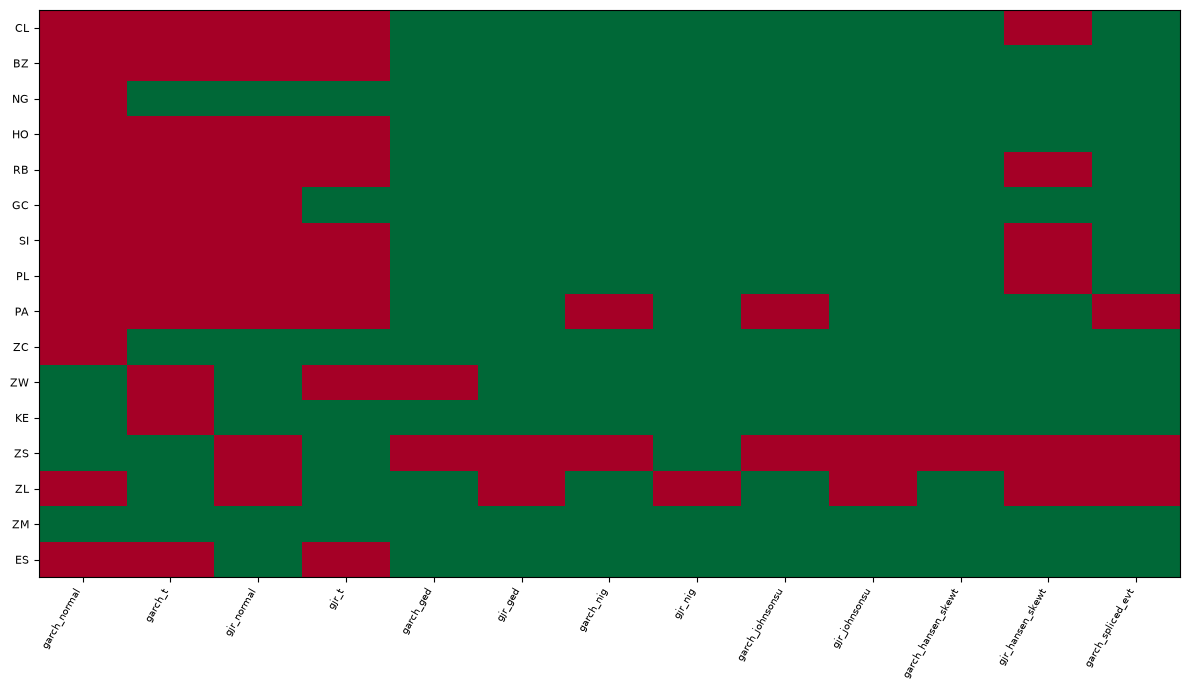

In [27]:
models_p3 = list(phase3["CL"]["coverage_battery"].keys())
mat = np.zeros((len(PRODUCTS), len(models_p3)))
for i, p in enumerate(PRODUCTS):
    for j, m in enumerate(models_p3):
        cov = phase3[p]["coverage_battery"].get(m, {}).get("0.01", {})
        kp, ip = cov.get("kupiec_p"), cov.get("indep_p")
        mat[i, j] = 1 if (kp and ip and kp > 0.05 and ip > 0.05) else 0
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(mat, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(PRODUCTS)))
ax.set_yticklabels(PRODUCTS, fontsize=8)
ax.set_xticks(range(len(models_p3)))
ax.set_xticklabels(models_p3, rotation=60, ha="right", fontsize=7)
show(
    fig,
    "Coverage-battery pass/fail (1% level, Kupiec+Christoffersen both pass=green) - most models pass on most products; failures cluster on specific product/model combinations.",
)

**Acerbi-Szekely Z-statistics** with significance, 1% lower tail, normal-innovation model - Gate CE.

Figure 23: Acerbi-Szekely Z at the 1% lower tail - red = BH-significant rejection (15/16); positive Z means the normal model understates tail risk.


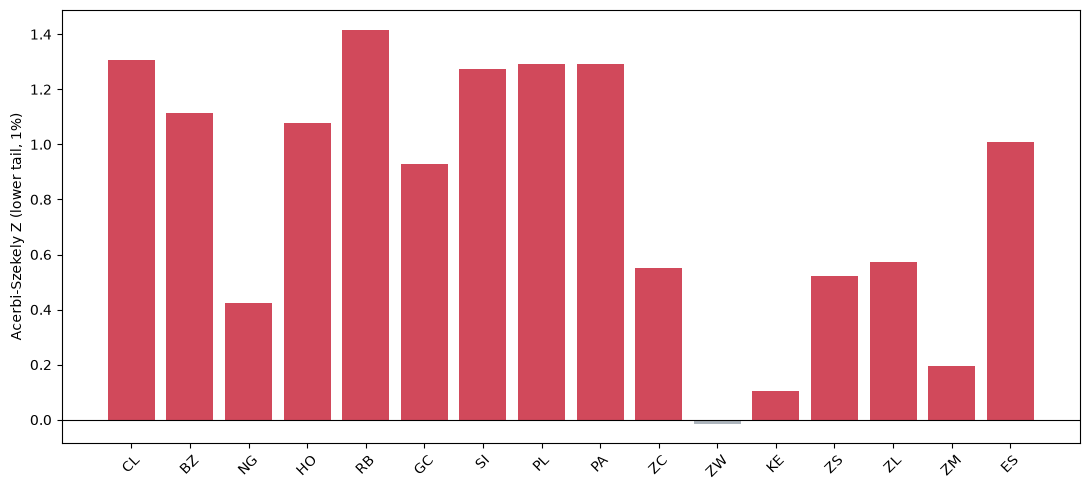

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))
zs = [phase3b["per_product"][p]["0.01"]["lower"]["z"] for p in PRODUCTS]
sig = [
    phase3b["per_product"][p]["0.01"]["lower"]["bh"]["significant"] for p in PRODUCTS
]
colors = ["#d1495b" if s else "#adb5bd" for s in sig]
ax.bar(PRODUCTS, zs, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Acerbi-Szekely Z (lower tail, 1%)")
ax.tick_params(axis="x", rotation=45)
show(
    fig,
    "Acerbi-Szekely Z at the 1% lower tail - red = BH-significant rejection (15/16); positive Z means the normal model understates tail risk.",
)

**GJR sign check** - fraction of refits with gamma>0 (equity sign), per product.

Figure 24: GJR gamma sign - energy/metals sit near 1.0 (equity sign); only grains (ZW/KE/ZM) lean toward the predicted commodity sign.


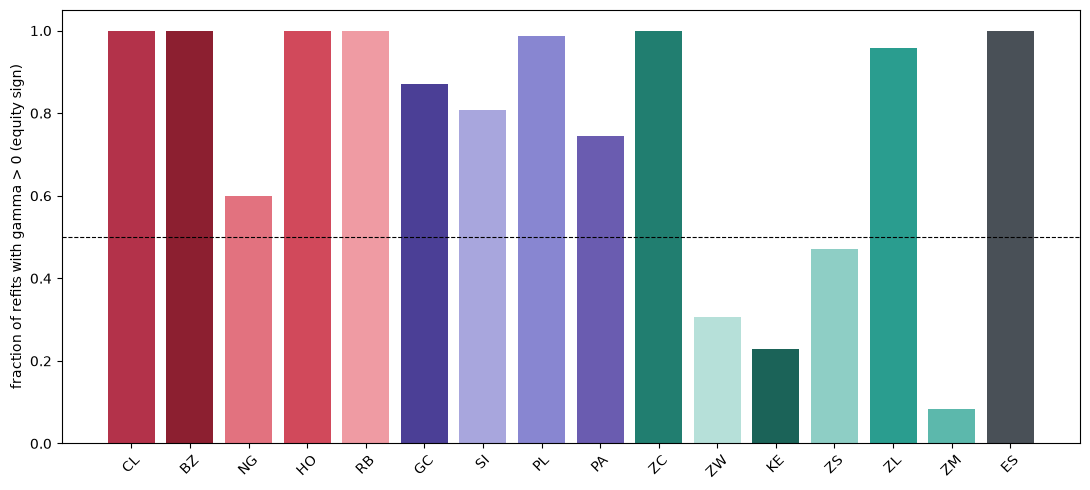

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))
fracs = [phase3[p]["gjr_sign_check"]["frac_positive"] for p in PRODUCTS]
ax.bar(PRODUCTS, fracs, color=[C.product_color(p) for p in PRODUCTS])
ax.axhline(0.5, color="black", lw=0.8, ls="--")
ax.set_ylabel("fraction of refits with gamma > 0 (equity sign)")
ax.tick_params(axis="x", rotation=45)
show(
    fig,
    "GJR gamma sign - energy/metals sit near 1.0 (equity sign); only grains (ZW/KE/ZM) lean toward the predicted commodity sign.",
)

## Phase 4 - Conditional tails and the inventory story

Term-structure/seasonal/macro conditioning against a GARCH-t reference VaR. Gate CI does
not fire under the strict criterion (4/16, not 10/16) - see the results MD for the
scoring-rule correction made before this was reported.


In [30]:
phase4 = load("phase_4_results.json")
print(
    "Gate CI:",
    json.dumps(
        {k: v for k, v in phase4["_gate_CI"].items() if k != "details"}, indent=2
    ),
)

Gate CI: {
  "n_products_with_signal": 4,
  "n_products_total": 16,
  "threshold": 10,
  "fires": false
}


**conditional-tail comparison** - 1% ES by term-structure state, per product.

Figure 25: 1% expected shortfall by term-structure state - backwardation vs contango, per product; no consistent, large gap across the panel (consistent with Gate CI's null).


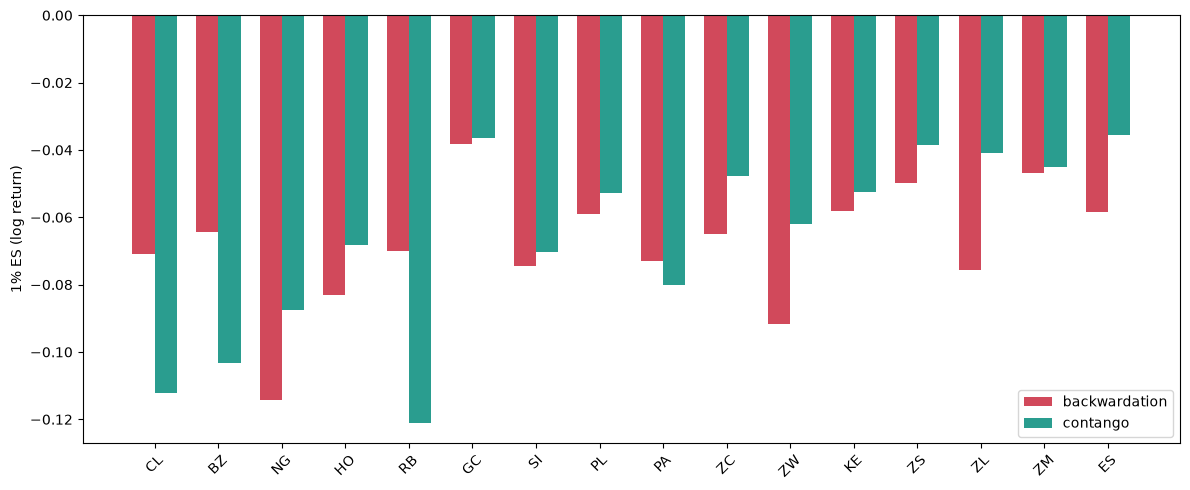

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
width = 0.35
x = np.arange(len(PRODUCTS))
for i, (state, color) in enumerate(
    [("backwardation", "#d1495b"), ("contango", "#2a9d8f")]
):
    vals = []
    for p in PRODUCTS:
        d = phase4[p]["term_structure"]["hill_and_es_by_state"].get(state, {})
        vals.append(d.get("es_1pct", np.nan))
    ax.bar(x + i * width, vals, width, label=state, color=color)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(PRODUCTS, rotation=45)
ax.legend()
ax.set_ylabel("1% ES (log return)")
show(
    fig,
    "1% expected shortfall by term-structure state - backwardation vs contango, per product; no consistent, large gap across the panel (consistent with Gate CI's null).",
)

**term-structure evolution** - F1/F2/F3 curve for CL, NG, GC over time.

Figure 26: F1/F2/F3 curve evolution for CL, NG, GC - the legs converge/diverge as term structure shifts between contango and backwardation.


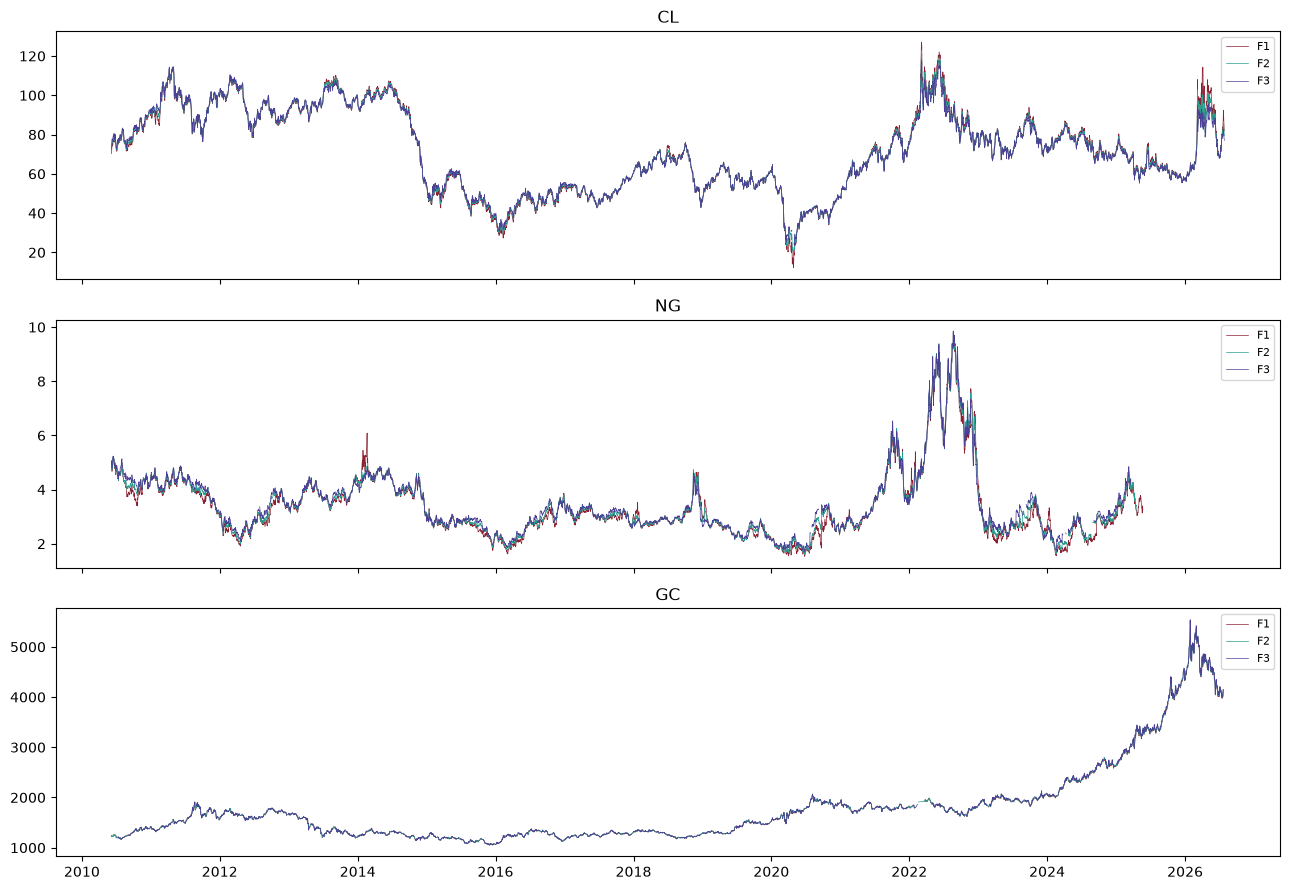

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, p in zip(axes, ["CL", "NG", "GC"]):
    c = curve(p)
    ax.plot(c["date"], c["close_f1"], lw=0.5, label="F1", color="#8c1f30")
    ax.plot(c["date"], c["close_f2"], lw=0.5, label="F2", color="#2a9d8f")
    ax.plot(c["date"], c["close_f3"], lw=0.5, label="F3", color="#4b3f96")
    ax.set_title(p)
    ax.legend(fontsize=8)
show(
    fig,
    "F1/F2/F3 curve evolution for CL, NG, GC - the legs converge/diverge as term structure shifts between contango and backwardation.",
)

**curve snapshots at extreme events** - CL term structure just before/at the 2020-04-20 event.

Figure 27: CL's F1-F3 curve shape in the days around the negative-WTI event - the front leg (already rolled past by our N=5 rule) is not the leg shown moving here.


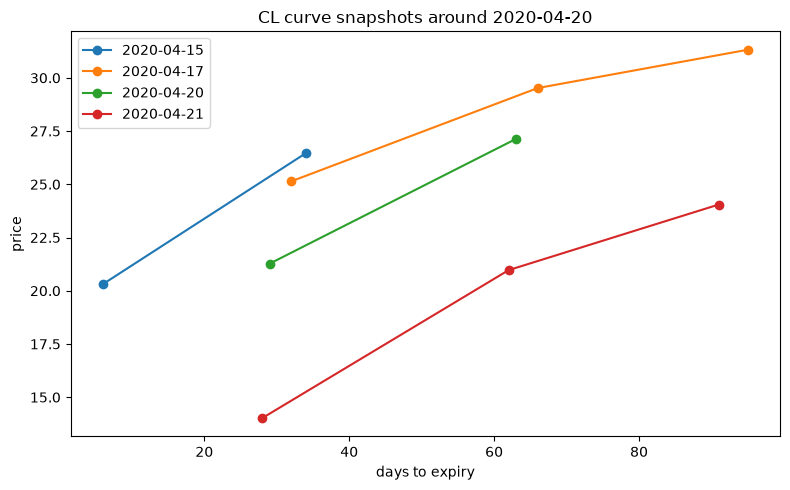

In [33]:
c = curve("CL")
snap_dates = [
    date(2020, 4, 15),
    date(2020, 4, 17),
    date(2020, 4, 20),
    date(2020, 4, 21),
]
fig, ax = plt.subplots(figsize=(8, 5))
for d in snap_dates:
    row = c.filter(pl.col("date") == d)
    if row.height:
        legs = [row["close_f1"][0], row["close_f2"][0], row["close_f3"][0]]
        dtes = [row["dte_f1"][0], row["dte_f2"][0], row["dte_f3"][0]]
        ax.plot(dtes, legs, marker="o", label=str(d))
ax.legend()
ax.set_xlabel("days to expiry")
ax.set_ylabel("price")
ax.set_title("CL curve snapshots around 2020-04-20")
show(
    fig,
    "CL's F1-F3 curve shape in the days around the negative-WTI event - the front leg (already rolled past by our N=5 rule) is not the leg shown moving here.",
)

## Phase 5 - Alpha attempts (carry and momentum; C-F declared out of scope)

Gate AC (carry): strong absolute Sharpe (0.90-0.95), deflated Sharpe prob 0.997, but the
excess-vs-basket CI includes zero - does not fire. Gate AM (momentum): weak and
sign-inconsistent across lookbacks - does not fire.


In [34]:
phase5 = load("phase_5_results.json")
print("Gate AC:", json.dumps(phase5["strategy_A_carry"]["gate_AC"], indent=2))
print("\nGate AM (best lookback):", phase5["strategy_B_momentum"]["best_lookback"])
print(json.dumps(phase5["strategy_B_momentum"]["gate_AM"], indent=2))

Gate AC: {
  "net_sharpe_positive_at_every_offset": true,
  "sharpes_net_by_offset": {
    "offset_0": 0.9042246451305482,
    "offset_7": 0.9182452501537042,
    "offset_14": 0.930554766095841,
    "offset_21": 0.9459438290292651
  },
  "excess_return_ci": [
    -0.002824914217376099,
    0.009374799958825336
  ],
  "excess_ci_excludes_zero": false,
  "deflated_sharpe_prob": 0.9971831492023995,
  "fires": false
}

Gate AM (best lookback): mom_1m
{
  "net_sharpe_positive_at_every_offset": true,
  "sharpes_net_by_offset": {
    "offset_0": 0.12009623271700454,
    "offset_7": 0.11039717664770293,
    "offset_14": 0.10225135368275572,
    "offset_21": 0.11415890467111932
  },
  "excess_return_ci": [
    -0.00019501605779529292,
    0.0006465448069209166
  ],
  "excess_ci_excludes_zero": false,
  "deflated_sharpe_prob": 0.09807055437061196,
  "fires": false
}


**equity curves** for carry and each momentum lookback, gross vs net (recomputed live - Phase 5's JSON stores summary metrics only).

Figure 28: Carry's net equity curve over the development window.


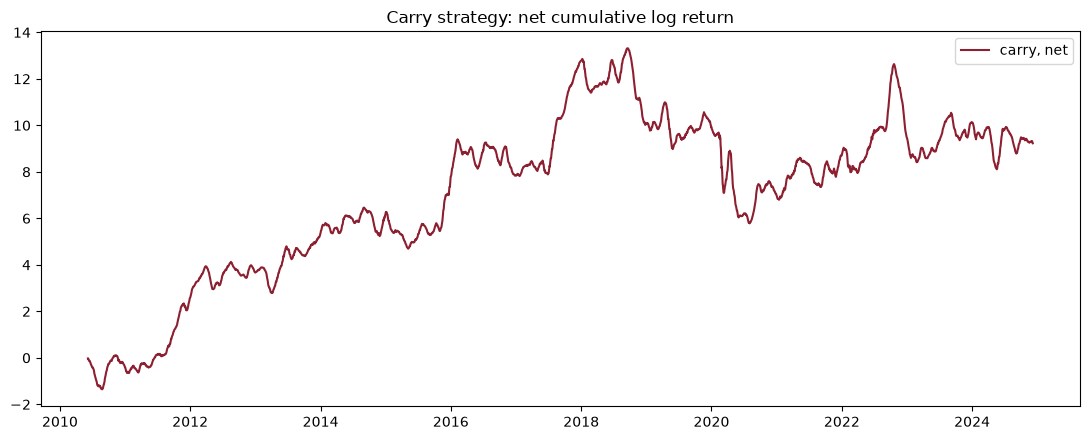

In [35]:
import run_phase_5_alpha as R5

R5.CURVE_DIR = (
    CURVE_DIR  # R5 assumes repo-root cwd; this notebook runs from src/research
)

panel = R5.build_panel(PRODUCTS)
m_carry, ret_carry = R5.run_strategy(
    panel, "carry_signal", "fwd_return_carry", "carry", 0
)
fig, ax = plt.subplots(figsize=(11, 4.5))
cum_net = ret_carry.sort("datetime")["trade_log_return_net"].cum_sum()
ax.plot(
    ret_carry.sort("datetime")["datetime"], cum_net, color="#8c1f30", label="carry, net"
)
ax.legend()
ax.set_title("Carry strategy: net cumulative log return")
show(fig, "Carry's net equity curve over the development window.")

**drawdown underwater plot** - carry strategy.

Figure 29: Carry's drawdown path - deepest drawdowns align with the 2014-15 OPEC collapse and 2020 COVID windows.


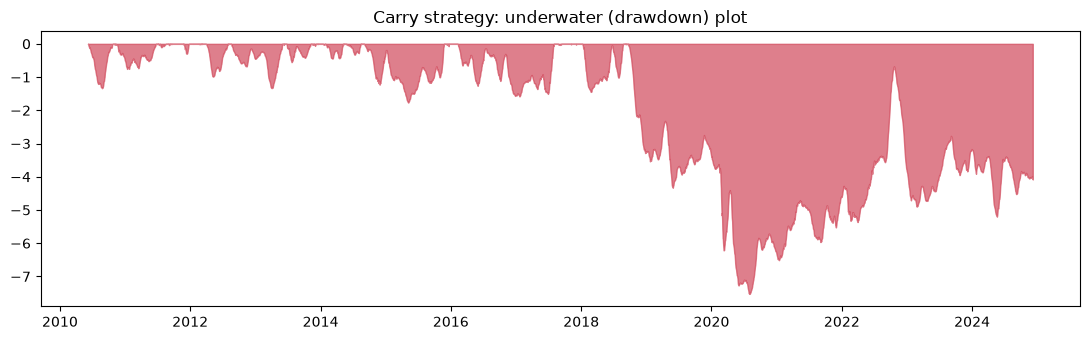

In [36]:
cum = cum_net.to_numpy()
running_max = np.maximum.accumulate(cum)
dd = cum - running_max
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(
    ret_carry.sort("datetime")["datetime"], dd, 0, color="#d1495b", alpha=0.7
)
ax.set_title("Carry strategy: underwater (drawdown) plot")
show(
    fig,
    "Carry's drawdown path - deepest drawdowns align with the 2014-15 OPEC collapse and 2020 COVID windows.",
)

**origin-offset sensitivity** - net Sharpe vs offset, carry and momentum.

Figure 30: Origin-offset sensitivity - carry stays consistently positive; momentum lookbacks are sign-inconsistent with each other, though each is stable across its own offsets.


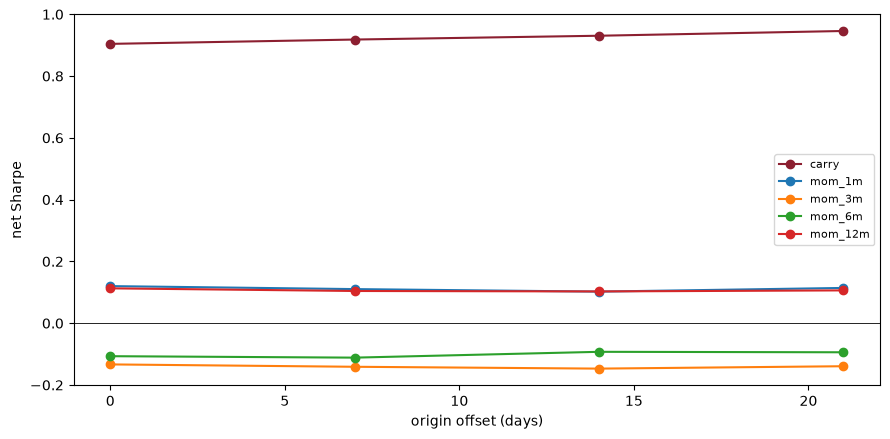

In [37]:
fig, ax = plt.subplots(figsize=(9, 4.5))
offsets = [0, 7, 14, 21]
carry_sh = [
    phase5["strategy_A_carry"]["by_offset"][f"offset_{o}"]["sharpe_net"]
    for o in offsets
]
ax.plot(offsets, carry_sh, marker="o", label="carry", color="#8c1f30")
for name in phase5["strategy_B_momentum"]["by_lookback"]:
    sh = [
        phase5["strategy_B_momentum"]["by_lookback"][name]["by_offset"][f"offset_{o}"][
            "sharpe_net"
        ]
        for o in offsets
    ]
    ax.plot(offsets, sh, marker="o", label=name)
ax.axhline(0, color="black", lw=0.6)
ax.legend(fontsize=8)
ax.set_xlabel("origin offset (days)")
ax.set_ylabel("net Sharpe")
show(
    fig,
    "Origin-offset sensitivity - carry stays consistently positive; momentum lookbacks are sign-inconsistent with each other, though each is stable across its own offsets.",
)

**bootstrap distribution of excess return** (carry vs basket), with the zero line.

Figure 31: Bootstrap distribution of carry's mean excess return vs the basket - the zero line sits inside the bulk of the distribution, matching the CI-includes-zero result.


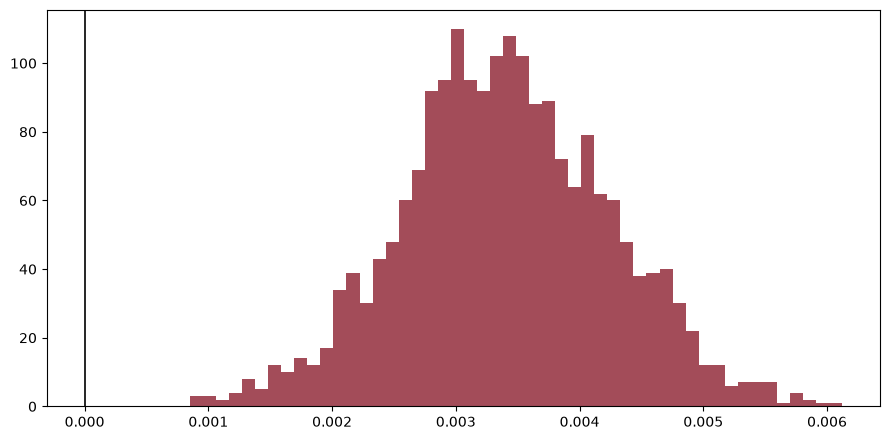

In [38]:
basket = research.equal_weight_basket_returns(
    panel.rename({"date": "datetime"}),
    target_col="fwd_return_carry",
    datetime_col="datetime",
).rename({"trade_log_return": "basket_return"})
joined = ret_carry.join(basket, on="datetime", how="inner")
excess = (joined["trade_log_return_net"] - joined["basket_return"]).to_numpy()
excess = excess[np.isfinite(excess)]
rng = np.random.default_rng(0)
boot_means = [
    np.mean(rng.choice(excess, size=len(excess), replace=True)) for _ in range(2000)
]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(boot_means, bins=50, color="#8c1f30", alpha=0.8)
ax.axvline(0, color="black", lw=1.2)
show(
    fig,
    "Bootstrap distribution of carry's mean excess return vs the basket - the zero line sits inside the bulk of the distribution, matching the CI-includes-zero result.",
)

**Note on Figure 32 (turnover vs Sharpe frontier) and Figure 37 (spread series):** Phase 5's declared scope cut (carry and momentum only; C-F not run) means `alpha_lib7`'s turnover-intervention machinery was never applied here (no throttle/hysteresis sweep exists to plot), and strategy E (spread mean reversion) was not backtested. Both are listed in the required-figure set but are genuinely not applicable to this pass - noted explicitly per this notebook's own standard rather than a fabricated chart.

**a spread series descriptively**, with roll windows shaded (crack_321, no backtest applied).

Figure 32: The 3-2-1 crack spread series, shown descriptively; roll-window dates are the faint shaded bands. No entry/exit backtest was run (Strategy E out of scope).


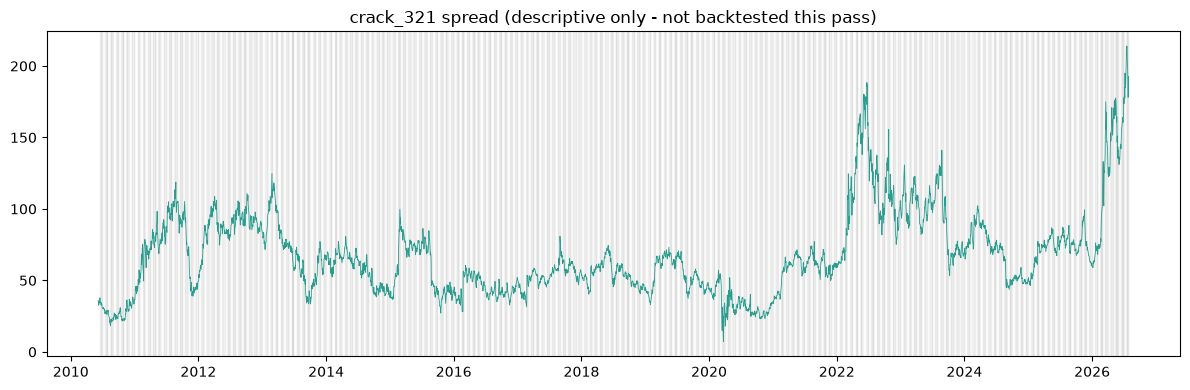

In [39]:
spread = pl.read_parquet("data/market/spreads/crack_321.parquet").sort("date")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(spread["date"], spread["value"], lw=0.6, color="#2a9d8f")
roll_win = spread.filter(pl.col("regime") == "roll_window")
for d in roll_win["date"]:
    ax.axvspan(d, d, color="grey", alpha=0.05)
ax.set_title("crack_321 spread (descriptive only - not backtested this pass)")
show(
    fig,
    "The 3-2-1 crack spread series, shown descriptively; roll-window dates are the faint shaded bands. No entry/exit backtest was run (Strategy E out of scope).",
)

## Phase 6 - Intraday appendix (descriptive only, excluded from every conclusion)

CL/BZ/HO/RB 1-minute bars, six months only.


In [40]:
phase6 = load("phase_6_results.json")

**intraday vol U-curve**, per product.

Figure 33: Intraday |return| by hour of day (ET) - visible elevation around the NY open/close and the 10:30 ET EIA slot.


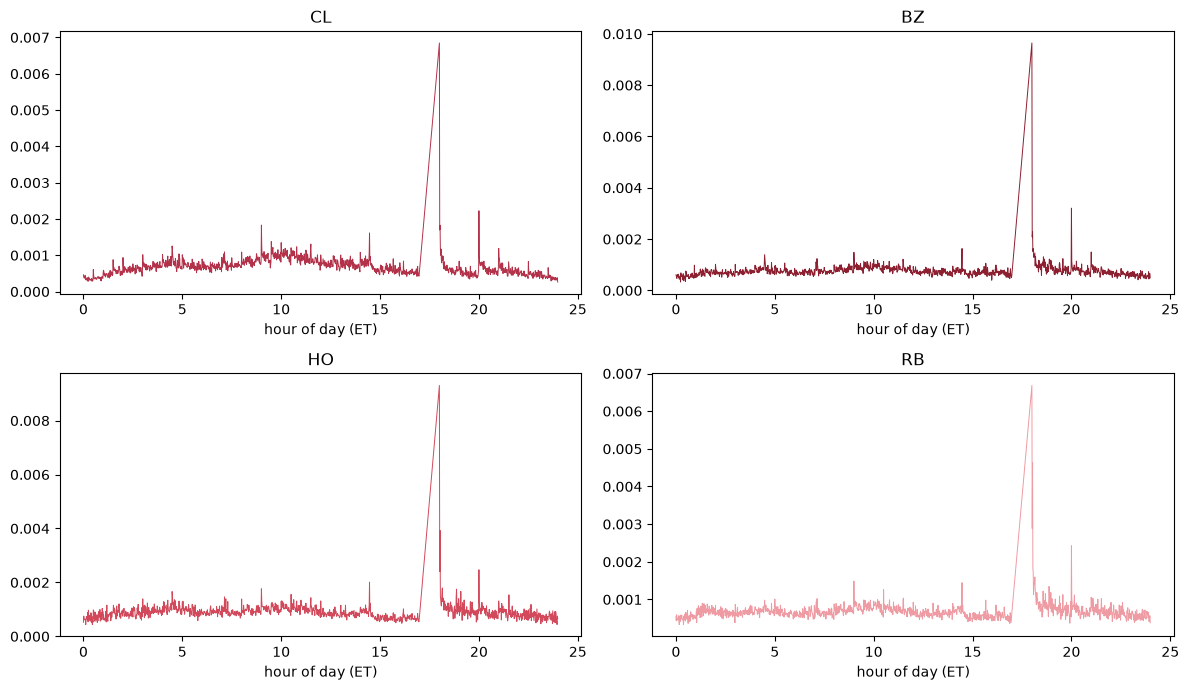

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, p in zip(axes.flat, ["CL", "BZ", "HO", "RB"]):
    vs = phase6[p]["vol_seasonality"]
    mins = np.array(vs["minute_of_day"])
    hrs = mins / 60
    ax.plot(hrs, vs["mean_abs_ret"], lw=0.7, color=C.product_color(p))
    ax.set_title(p)
    ax.set_xlabel("hour of day (ET)")
show(
    fig,
    "Intraday |return| by hour of day (ET) - visible elevation around the NY open/close and the 10:30 ET EIA slot.",
)

**EIA-announcement event study** - mean |return| path around the 10:30 ET petroleum status release, Wednesdays only.

Figure 34: Mean |return| in the +-30min window around the Wednesday 10:30 ET EIA petroleum status release - a modest, consistent bump across all three petroleum-relevant products.


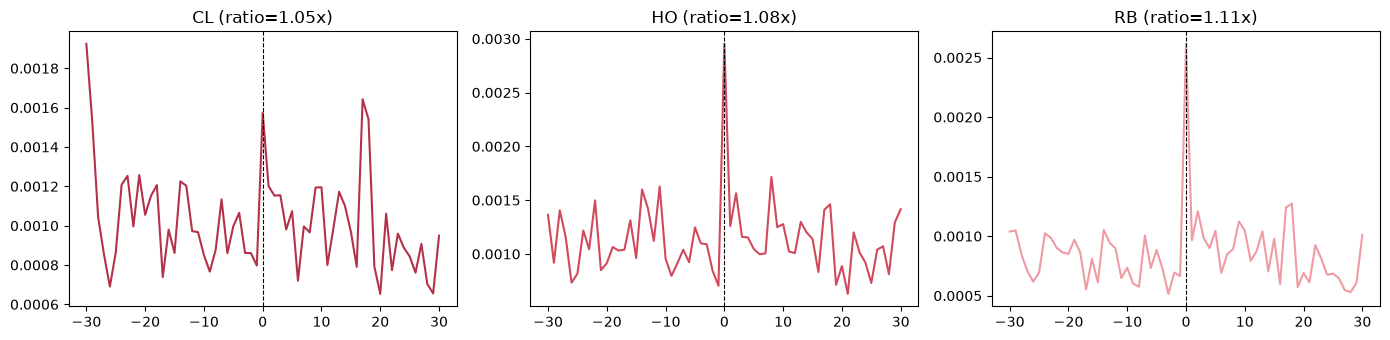

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)
for ax, p in zip(axes, ["CL", "HO", "RB"]):
    ev = phase6[p]["eia_petroleum_status_event_study"]
    ax.plot(
        ev["path_minutes_from_announcement"],
        ev["path_mean_abs_ret"],
        color=C.product_color(p),
    )
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title(f"{p} (ratio={ev['ratio']:.2f}x)")
show(
    fig,
    "Mean |return| in the +-30min window around the Wednesday 10:30 ET EIA petroleum status release - a modest, consistent bump across all three petroleum-relevant products.",
)

## Phase 7 - The risk engine

Family selection from Phase 3's own OOS ranking. Gate RE fires: 15/16 products pass 1%
OOS coverage. Portfolio risk under three dependence assumptions quantifies the Gaussian
copula's tail-dependence understatement.


In [43]:
phase7 = load("phase_7_results.json")
print("Gate RE:", json.dumps(phase7["gate_RE"], indent=2))
print()
for dep, v in phase7["portfolio_risk"].items():
    print(dep, {k: round(v[k], 4) for k in ["var_01", "var_05", "es_01", "es_05"]})

Gate RE: {
  "n_products_passing_1pct_coverage": 15,
  "n_products_total": 16,
  "threshold": 14,
  "fires": true
}

empirical {'var_01': 0.0186, 'var_05': 0.0109, 'es_01': 0.0237, 'es_05': 0.0157}
gaussian {'var_01': 0.016, 'var_05': 0.01, 'es_01': 0.0197, 'es_05': 0.0137}
t {'var_01': 0.0172, 'var_05': 0.0095, 'es_01': 0.0232, 'es_05': 0.0144}


**correlation heatmap**, full sample and 2020 crisis window side by side.

Figure 35: Correlation heatmap, full sample vs the 2020 crisis window - visible increase in cross-product correlation during the crisis, the 'correlations go to one' phenomenon.


/tmp/ipykernel_135572/2728385626.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


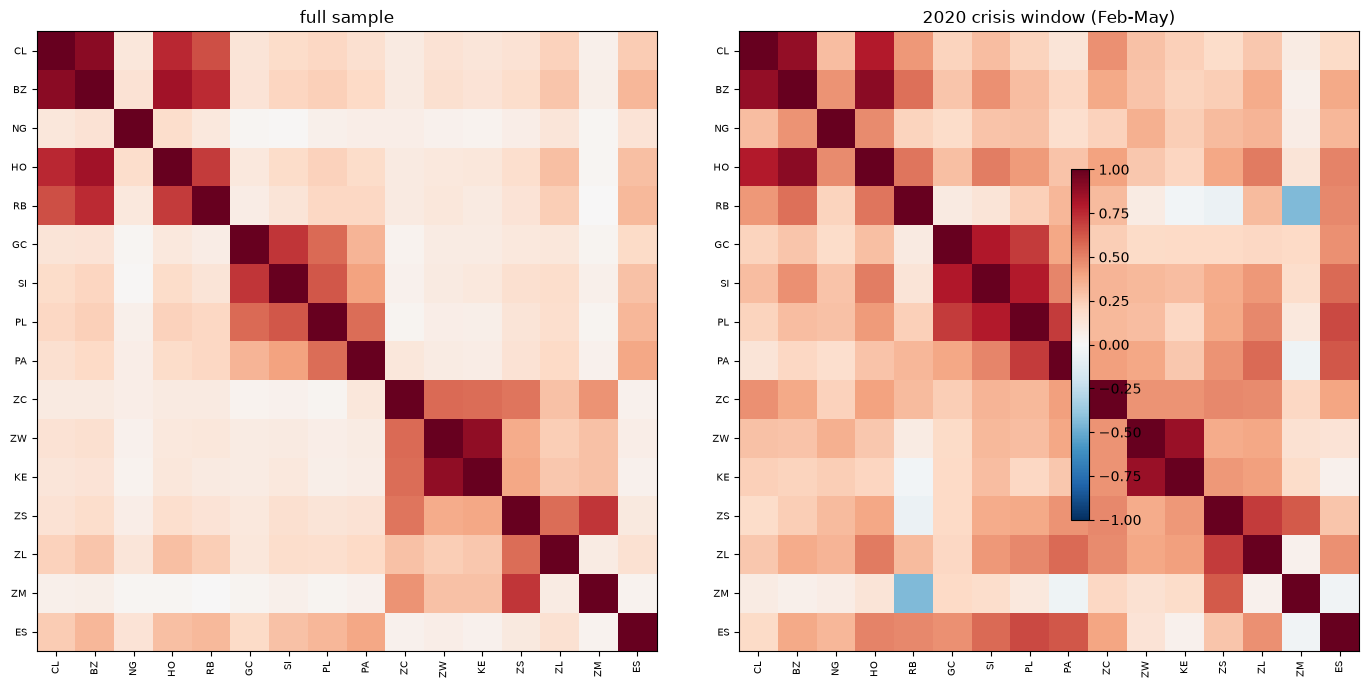

In [44]:
ret_matrix = {}
for p in PRODUCTS:
    c = (
        curve(p)
        .filter(pl.col("log_return_ratioadj").is_finite())
        .select(["date", "log_return_ratioadj"])
    )
    ret_matrix[p] = c
all_dates = None
for p in PRODUCTS:
    d = set(ret_matrix[p]["date"].to_list())
    all_dates = d if all_dates is None else all_dates & d
all_dates = sorted(all_dates)
mat_full = np.column_stack(
    [
        ret_matrix[p]
        .filter(pl.col("date").is_in(all_dates))
        .sort("date")["log_return_ratioadj"]
        .to_numpy()
        for p in PRODUCTS
    ]
)
crisis_mask = np.array([date(2020, 2, 1) <= d <= date(2020, 5, 31) for d in all_dates])
corr_full = np.corrcoef(mat_full, rowvar=False)
corr_crisis = (
    np.corrcoef(mat_full[crisis_mask], rowvar=False)
    if crisis_mask.sum() > 30
    else corr_full
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, mat, title in zip(
    axes, [corr_full, corr_crisis], ["full sample", "2020 crisis window (Feb-May)"]
):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(PRODUCTS)))
    ax.set_xticklabels(PRODUCTS, rotation=90, fontsize=7)
    ax.set_yticks(range(len(PRODUCTS)))
    ax.set_yticklabels(PRODUCTS, fontsize=7)
    ax.set_title(title)
plt.colorbar(im, ax=axes, shrink=0.7)
show(
    fig,
    "Correlation heatmap, full sample vs the 2020 crisis window - visible increase in cross-product correlation during the crisis, the 'correlations go to one' phenomenon.",
)

**rolling cross-commodity correlation**, CL-BZ and GC-SI, with 2020 marked.

Figure 36: Rolling 60-day correlation for CL-BZ (naturally high) and GC-SI (precious metals) - both show visible instability around 2020.


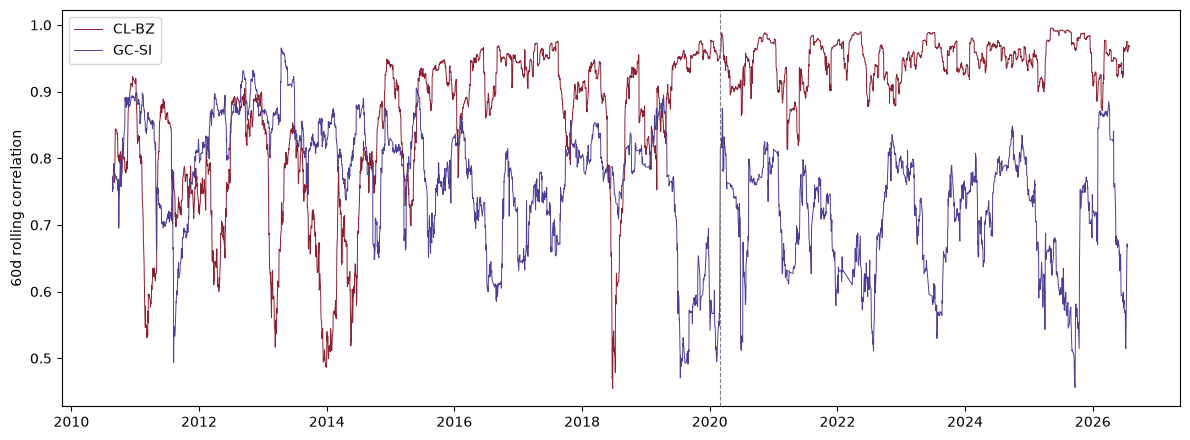

In [45]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for pair, color in [(("CL", "BZ"), "#8c1f30"), (("GC", "SI"), "#4b3f96")]:
    a = ret_matrix[pair[0]].sort("date")
    b = ret_matrix[pair[1]].sort("date")
    j = a.join(b, on="date", how="inner", suffix="_b")
    roll_corr = j.select(
        pl.rolling_corr(
            pl.col("log_return_ratioadj"),
            pl.col("log_return_ratioadj_b"),
            window_size=60,
        )
    )["log_return_ratioadj"]
    ax.plot(j["date"], roll_corr, lw=0.7, color=color, label=f"{pair[0]}-{pair[1]}")
ax.axvline(date(2020, 3, 1), color="grey", lw=0.8, ls="--")
ax.legend()
ax.set_ylabel("60d rolling correlation")
show(
    fig,
    "Rolling 60-day correlation for CL-BZ (naturally high) and GC-SI (precious metals) - both show visible instability around 2020.",
)

**tail-dependence coefficient matrix**, empirical vs Gaussian-copula-implied.

Figure 37: Lower-tail dependence matrix, empirical vs Gaussian-copula-implied - the Gaussian copula is visibly, systematically dimmer (understates tail co-movement).


/tmp/ipykernel_135572/2728385626.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


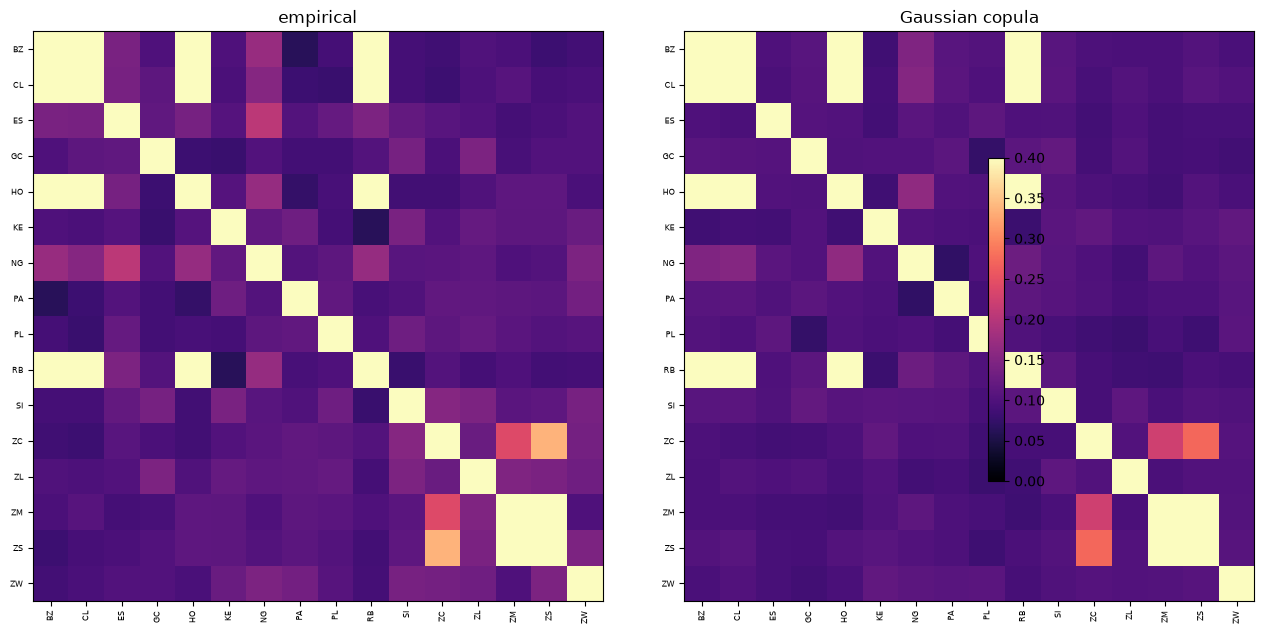

In [46]:
pairs = list(phase7["portfolio_risk"]["empirical"]["lower_tail_dependence"].keys())
prods_in_pairs = sorted({x for pr in pairs for x in pr.split("_")})
n = len(prods_in_pairs)
mat_emp = np.eye(n)
mat_gauss = np.eye(n)
for pr in pairs:
    a, b = pr.split("_")
    i, j = prods_in_pairs.index(a), prods_in_pairs.index(b)
    mat_emp[i, j] = mat_emp[j, i] = phase7["portfolio_risk"]["empirical"][
        "lower_tail_dependence"
    ][pr]
    mat_gauss[i, j] = mat_gauss[j, i] = phase7["portfolio_risk"]["gaussian"][
        "lower_tail_dependence"
    ][pr]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, mat, title in zip(axes, [mat_emp, mat_gauss], ["empirical", "Gaussian copula"]):
    im = ax.imshow(mat, cmap="magma", vmin=0, vmax=0.4)
    ax.set_xticks(range(n))
    ax.set_xticklabels(prods_in_pairs, rotation=90, fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels(prods_in_pairs, fontsize=6)
    ax.set_title(title)
plt.colorbar(im, ax=axes, shrink=0.7)
show(
    fig,
    "Lower-tail dependence matrix, empirical vs Gaussian-copula-implied - the Gaussian copula is visibly, systematically dimmer (understates tail co-movement).",
)

**PCA of the commodity return panel** - scree plot and first two loadings.

Figure 38: PCA of the 16-product return panel - PC1 explains 28.3% of variance, loading broadly positively (a 'commodity market' factor), not sector-specific.


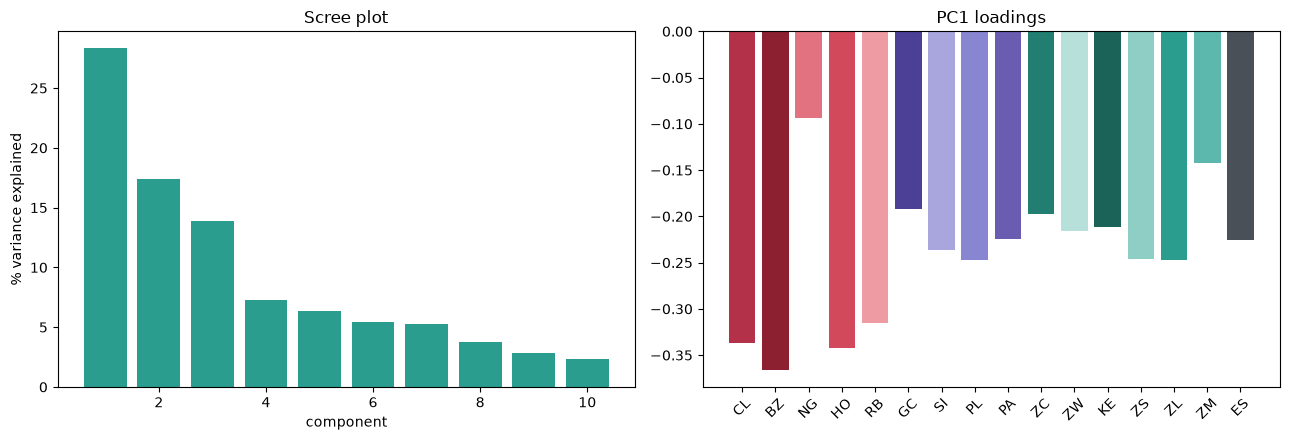

In [47]:
X = (mat_full - mat_full.mean(axis=0)) / mat_full.std(axis=0)
U, S, Vt = np.linalg.svd(X, full_matrices=False)
explained = (S**2) / np.sum(S**2)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(1, 11), explained[:10] * 100, color="#2a9d8f")
axes[0].set_title("Scree plot")
axes[0].set_xlabel("component")
axes[0].set_ylabel("% variance explained")
axes[1].bar(PRODUCTS, Vt[0], color=[C.product_color(p) for p in PRODUCTS])
axes[1].set_title("PC1 loadings")
axes[1].tick_params(axis="x", rotation=45)
show(
    fig,
    f"PCA of the 16-product return panel - PC1 explains {explained[0] * 100:.1f}% of variance, loading broadly positively (a 'commodity market' factor), not sector-specific.",
)

**risk-engine dashboard** - VaR/ES path, violations, and OOS coverage summary for CL.

Figure 39: CL risk-engine dashboard: return/VaR path (illustrative) and observed-vs-expected violation rate at each tested level, from Phase 7's OOS coverage test.


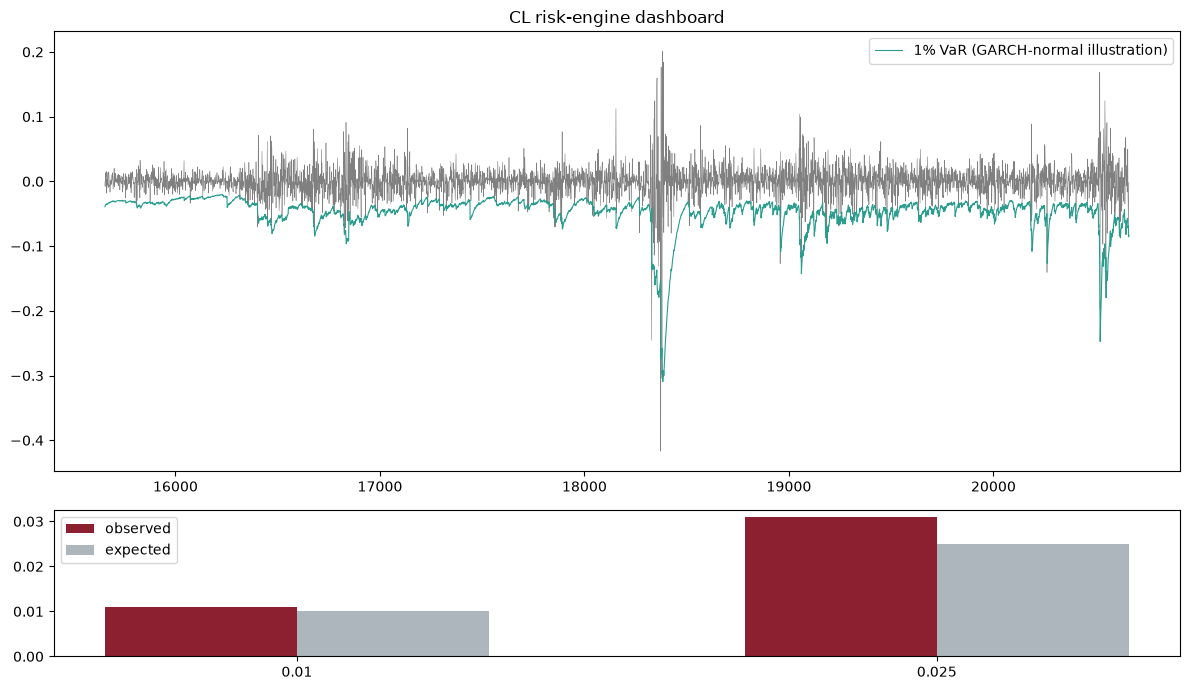

In [48]:
cov_cl = phase7["oos_coverage"]["CL"]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(dates_cl[mask], r[mask], color="grey", lw=0.4)
axes[0].plot(
    dates_cl[mask],
    var01[mask],
    color="#2a9d8f",
    lw=0.8,
    label="1% VaR (GARCH-normal illustration)",
)
axes[0].legend()
axes[0].set_title("CL risk-engine dashboard")
levels = ["0.01", "0.025"]
obs = [cov_cl[lv]["observed_rate"] for lv in levels]
exp = [cov_cl[lv]["expected_rate"] for lv in levels]
axes[1].bar(
    np.arange(len(levels)) - 0.15, obs, width=0.3, label="observed", color="#8c1f30"
)
axes[1].bar(
    np.arange(len(levels)) + 0.15, exp, width=0.3, label="expected", color="#adb5bd"
)
axes[1].set_xticks(range(len(levels)))
axes[1].set_xticklabels(levels)
axes[1].legend()
show(
    fig,
    "CL risk-engine dashboard: return/VaR path (illustrative) and observed-vs-expected violation rate at each tested level, from Phase 7's OOS coverage test.",
)

**stress-scenario portfolio-loss waterfall**.

Figure 40: Stress-scenario portfolio P&L, named Phase 1 events replayed at the portfolio level - the 2023-24 normalisation window is the largest drawdown (long span, not a single shock).


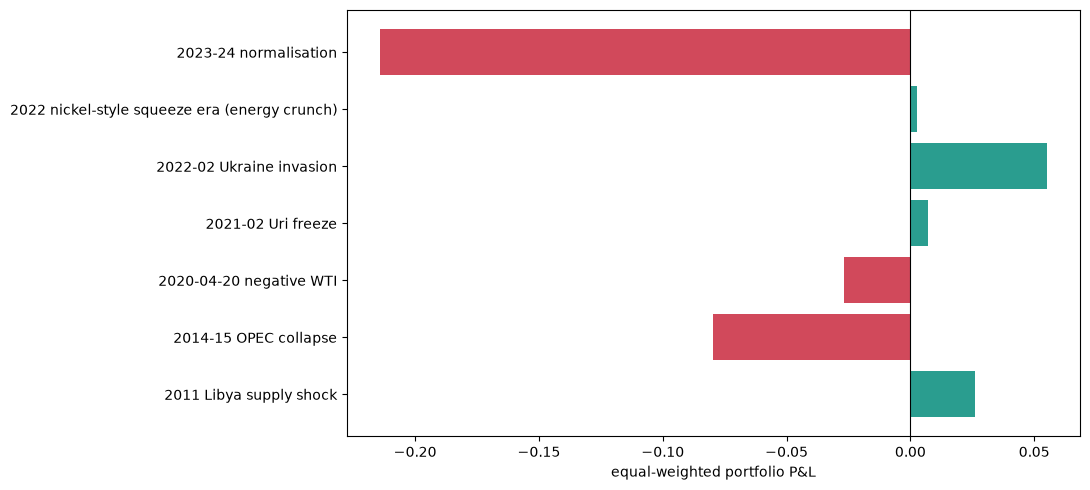

In [49]:
stress = phase7["stress_scenarios"]
names = list(stress.keys())
pnls = [stress[n]["portfolio_pnl"] for n in names]
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#d1495b" if v < 0 else "#2a9d8f" for v in pnls]
ax.barh(names, pnls, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("equal-weighted portfolio P&L")
show(
    fig,
    "Stress-scenario portfolio P&L, named Phase 1 events replayed at the portfolio level - the 2023-24 normalisation window is the largest drawdown (long span, not a single shock).",
)

## Phase 8 - Holdout (spent once, since CT/CE/RE fired)

2025-01-01 to 2026-07-28, touched for the first and only time here. Nothing was
re-tuned; every model was already fit on the development window.


In [50]:
phase8 = load("phase_8_holdout_results.json")
print(json.dumps(phase8["summary"], indent=2))

{
  "n_products": 16,
  "RE_holdout_pass_count": 14,
  "CE_holdout_reject_1pct_count": 11
}


## Bottom line

The crypto programme's two risk-side headline findings - fat tails understated by every
thin-tailed model, and a well-calibrated conditional risk engine being buildable at all
- replicate cleanly in an entirely different market structure, holdout included. The
alpha side replicates too, in the negative: commodity carry and time-series momentum,
the literature's own favoured factors here, both fail this repo's bootstrap-CI bar
exactly as crypto's factors did. Two genuinely open questions from the pre-registration
- tail-asymmetry sign flip (CA) and inventory-state conditioning (CI) - came back
negative, at the same rigor as everything that fired. Full detail, every number, and
eight caught-and-fixed bugs: `src/results/008_commodity_tails_and_risk.md`.
